# GuarantorLens - the complete ML pipeline (one notebook)

This single notebook is the **whole machine-learning pipeline**, explained step by step and kept simple:

1. **Merge** the two source files into one labeled dataset.
2. Name the **target label** and drop anything known only *after* the loan is decided (leakage).
3. **EDA** - class imbalance, distributions, and how features separate good from bad loans.
4. **Feature engineering**, including the **guarantee-network** features (communities, as-of history).
5. **Split** the data fairly (each borrower is wholly in train or test).
6. Train **five model families** with a **RandomizedSearchCV** experiment engine (a set number of experiments per model, not a fixed grid).
7. For each model: a **hyperparameter table** (best experiment highlighted), a **confusion matrix**, and a **learning / loss curve**.
8. Pick the **overall best**, check whether the **network** adds signal, tune the class weight (`scale_pos_weight`).
9. **Calibrate**, add **monotone constraints**, and **export** the served model bundle.
10. The **other models**: network communities + contagion, **survival analysis**, **clustering + anomaly**, and their bundle.
11. Worked **test cases** and a **download** of everything.

**How to run (Colab):** upload `Normal.xlsx` and `Written Off.xlsx`, then Run all. Pickles use scikit-learn 1.6.1 to match the app.

## Setting Up and loading the data

In [1]:
import warnings, os, json, shutil
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from bisect import bisect_left

RANDOM_STATE = 42
COHORT_START, COHORT_END = "2022-01-01", "2023-12-31"   # the disbursement window we were given
TARGET_RECALL = 0.80
NORMAL_FILE, WRITTENOFF_FILE = "Normal.xlsx", "Written Off.xlsx"

try:
    from google.colab import files
    ON_COLAB = True
except Exception:
    ON_COLAB = False

if ON_COLAB:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "xgboost", "imbalanced-learn", "shap", "openpyxl", "networkx"])
    DATASET_DIR = Path(".")
    have = {p.name for p in DATASET_DIR.glob("*.xlsx")}
    if not ({NORMAL_FILE, WRITTENOFF_FILE} <= have):
        print("Upload BOTH files: 'Normal.xlsx' and 'Written Off.xlsx'")
        files.upload()
else:
    DATASET_DIR = Path("data/Dataset")

OUTPUT_DIR = Path("models/guarantorlens_new"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for f in (NORMAL_FILE, WRITTENOFF_FILE):
    assert (DATASET_DIR / f).exists(), f"Missing {f}. On Colab, re-run and upload it."
print("data folder:", DATASET_DIR.resolve())
# --- clearer, larger figures for the report ---
plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
    'figure.dpi': 110, 'savefig.dpi': 160, 'savefig.bbox': 'tight',
})


# --- save every printed line to a run log (shown AND written to disk) ---
import sys as _sys
class _Tee:
    def __init__(self, path):
        self._term = _sys.__stdout__; self._log = open(path, "w", encoding="utf-8")
    def write(self, s): self._term.write(s); self._log.write(s); self._log.flush()
    def flush(self):
        self._term.flush(); self._log.flush()
    def isatty(self): return False
LOG_PATH = OUTPUT_DIR / "run_log.txt"
_sys.stdout = _Tee(str(LOG_PATH))
print("run log ->", LOG_PATH)

Upload BOTH files: 'Normal.xlsx' and 'Written Off.xlsx'


##  The label, and features we are allowed to use

A loan in `Written Off.xlsx` is a **default (1)**; a loan in `Normal.xlsx`
is **good (0)**. (Repayment Status inside the files is only the *recovery* state - a write-off
that was later repaid is still a write-off, so we never use it as the label.)

Some columns only exist *after* the loan is decided (arrears, repayment status, unpaid amounts,
last payment date). Using them would be cheating, so we drop them and keep only what an officer
knows **on the day the loan is given**.

In [2]:
OUTCOME_COLS = ["Days in Arrears","Repayment Status","Non Paid Capital","Non Paid Interest",
                "Non Paid Penalty","Non Paid Insurance","Last Payment Date"]

# leak-free individual (borrower/loan) features, all known at origination
IND_CANDIDATES = ["log_amount","savings","salary","interest_rate","loan_to_savings",
                  "loan_to_salary","account_age","b_prior_loans","b_prior_writeoff",
                  "b_prior_arrears_rate","time_since_last_loan","b_recent_loans"]
# candidate guarantor-network features (screened for time leakage below)
NET_CANDIDATES = ["n_guarantors","g_mean_savings","g_mean_salary","g_prior_default_rate",
                  "g_prior_arrears_rate","g_sav_ratio","community_prior_default_rate"]

## Load the two files (dataset)

Each row is one **(loan, guarantor)** pair. We tag the label by file, read the branch from the
`Branch Name` column, and if a loan somehow appears in both files the **write-off wins**.

In [3]:
def load_labeled(path, label):
    xl = pd.ExcelFile(path)
    d = pd.concat([pd.read_excel(path, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
    d["label"] = label
    return d

normal = load_labeled(DATASET_DIR / NORMAL_FILE, 0)
writ   = load_labeled(DATASET_DIR / WRITTENOFF_FILE, 1)
normal = normal[~normal["Loan ID"].isin(set(writ["Loan ID"]))]   # write-off wins on overlap
raw = pd.concat([normal, writ], ignore_index=True)
raw["branch"] = raw["Branch Name"].astype(str).str.strip()
for c in ["Disbursement Date","Customer Opening Date"]:
    raw[c] = pd.to_datetime(raw[c], errors="coerce")
for c in ["Disbursement Amount","Savings","Salary","Interest Rate","Days in Arrears"]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
print("rows:", len(raw), "| loans:", raw['Loan ID'].nunique(), "| branches:", raw['branch'].nunique())

## One row per loan

We collapse to one row per loan with its list of guarantors, and a `troubled` flag (written off,
or 30+ days in arrears) that we only ever read for a member's **earlier** loans, so it stays
leak-free.

In [4]:
agg = {"Borrower ID":"first","branch":"first","label":"first","Disbursement Amount":"first",
       "Disbursement Date":"first","Customer Opening Date":"first","Savings":"first",
       "Salary":"first","Interest Rate":"first","Days in Arrears":"first"}
loans = raw.groupby("Loan ID").agg(agg).reset_index()
guar = raw.groupby("Loan ID")["Guarantor ID"].apply(lambda s: [x for x in s.dropna().unique()])
loans["guarantors"] = loans["Loan ID"].map(guar.to_dict())
loans["n_guarantors"] = loans["guarantors"].apply(len)
loans["troubled"] = ((loans.label == 1) | (loans["Days in Arrears"] >= 30)).astype(int)

by = loans.groupby(loans.label.map({0:"Normal",1:"Written off"}))["n_guarantors"].agg(["size","median","mean"])
print("guarantors per loan by outcome:"); print(by.to_string())
print(f"\nloans={len(loans)}  defaults={loans.label.sum()}  bad_rate={loans.label.mean():.1%}  branches={loans.branch.nunique()}")

## The merged, labeled dataset
The two files are now one clean table, one row per loan, with the 0/1 label.

In [5]:
# The merged, labeled modelling dataset: the two source files joined into ONE row per loan.
merged = loans.copy()
merged["outcome"] = np.where(merged.label == 1, "Written off", "Normal")

# --- the TARGET LABEL, printed explicitly ---
print("TARGET LABEL:  1 = Written off (default)   0 = Normal (good loan)")
print(merged.label.map({0: "0 = Normal (good)", 1: "1 = Written off (default)"}).value_counts().to_string())
print(f"bad rate (share defaulting) = {merged.label.mean():.2%}")

# --- the merged dataset, saved and displayed ---
_keep = ["Loan ID","Borrower ID","branch","Disbursement Date","Disbursement Amount","Savings","Salary",
         "Interest Rate","n_guarantors","label","outcome"]
merged[_keep].to_csv(OUTPUT_DIR/"00_merged_dataset.csv", index=False)
print(f"\nMERGED dataset: {merged.shape[0]:,} loans x {merged.shape[1]} columns  |  {merged.branch.nunique()} branches")
_show = merged[["Loan ID","Borrower ID","branch","Disbursement Amount","Savings","Interest Rate","n_guarantors","outcome"]].head(8)
try:
    from IPython.display import display; print("\nfirst rows of the merged dataset:"); display(_show)
except Exception:
    print("\nfirst rows of the merged dataset:"); print(_show.to_string(index=False))

,Loan ID,Borrower ID,branch,Disbursement Amount,Savings,Interest Rate,n_guarantors,outcome
0,Loan2617805,Client61671,Gasabo,950000,193780,13,2,Normal
1,Loan2617915,Client44718,Gasabo,830000,2084870,13,2,Normal
2,Loan2618915,Client3721,Rubavu,593000,510235,13,3,Normal
3,Loan2618917,Client63974,Rubavu,1039000,251712,13,3,Normal
4,Loan2619455,Client30252,Nyarugenge,1450000,543535,13,2,Normal
5,Loan2619570,Client31585,Rusizi,2700000,1950466,13,2,Normal
6,Loan2619812,Client119430,Rubavu,2440000,249569,13,4,Normal
7,Loan2619917,Client350,Rusizi,1320000,956580,13,3,Normal


## Building the features

For every loan we only look at each member's **earlier** loans, never later ones. Borrower
features come from their own history; guarantor features from each guarantor's own record and the
loans they had already backed. We also build a **community** feature: the past default rate of the
borrower's wider guarantee cluster (connected component in the guarantee graph), computed as-of.

In [6]:
# --- guarantee graph -> communities (union-find) ---
parent = {}
def find(x):
    parent.setdefault(x, x)
    while parent[x] != x: parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb: parent[ra] = rb
for _, r in loans.iterrows():
    for g in r["guarantors"]: union(r["Borrower ID"], g)
loans["comm"] = loans["Borrower ID"].map(find)

# per-community time-sorted (date,label) for an AS-OF community default rate (leak-free)
comm_hist = {}
for _, r in loans.iterrows():
    comm_hist.setdefault(find(r["Borrower ID"]), []).append((r["Disbursement Date"], r["label"]))
for c in comm_hist: comm_hist[c] = sorted((d, l) for d, l in comm_hist[c] if pd.notna(d))
def comm_prior_rate(comm, d):
    h = comm_hist.get(comm, [])
    if not h or pd.isna(d): return np.nan
    earlier = [l for dd, l in h[:bisect_left([x[0] for x in h], d)]]
    return float(np.mean(earlier)) if earlier else np.nan

# --- member histories (as-of) ---
bmap = loans.groupby("Borrower ID").agg(sav=("Savings","median"), sal=("Salary","median")).to_dict("index")
member_loans, guar_backed = {}, {}
for _, r in loans.iterrows():
    member_loans.setdefault(r["Borrower ID"], []).append((r["Disbursement Date"], r["label"], r["troubled"]))
    for g in r["guarantors"]:
        guar_backed.setdefault(g, []).append((r["Disbursement Date"], r["troubled"]))
def earlier(mid, d):
    return [(dt, lb, tr) for dt, lb, tr in member_loans.get(mid, []) if pd.notna(dt) and pd.notna(d) and dt < d]
def earlier_backed(g, d):
    return [(dt, tr) for dt, tr in guar_backed.get(g, []) if pd.notna(dt) and pd.notna(d) and dt < d]

rows = []
for _, r in loans.iterrows():
    d, amt, sav, sal, gs = r["Disbursement Date"], r["Disbursement Amount"], r["Savings"], r["Salary"], r["guarantors"]
    gsav = [bmap[g]["sav"] for g in gs if g in bmap]; gsal = [bmap[g]["sal"] for g in gs if g in bmap]
    gms = float(np.mean(gsav)) if gsav else np.nan
    age = ((d - r["Customer Opening Date"]).days/365.25) if pd.notna(d) and pd.notna(r["Customer Opening Date"]) else np.nan
    ph = earlier(r["Borrower ID"], d); last = max([dt for dt,_,_ in ph]) if ph else None
    gdf, gba = [], []
    for g in gs:
        gdf.append(int(any(lb == 1 for _, lb, _ in earlier(g, d))))
        bk = earlier_backed(g, d); gba.append(float(np.mean([t for _, t in bk])) if bk else 0.0)
    rows.append(dict(
        loan=r["Loan ID"], borrower=r["Borrower ID"], label=r["label"], branch=r["branch"], disb_date=d,
        log_amount=np.log1p(amt), savings=sav, salary=sal, interest_rate=r["Interest Rate"],
        loan_to_savings=amt/max(sav,1.0) if pd.notna(sav) else np.nan,
        loan_to_salary=amt/max(sal,1.0) if pd.notna(sal) else np.nan,
        account_age=age, b_prior_loans=len(ph), b_prior_writeoff=int(any(lb==1 for _,lb,_ in ph)),
        b_prior_arrears_rate=float(np.mean([t for _,_,t in ph])) if ph else 0.0,
        time_since_last_loan=((d-last).days/365.25) if last else np.nan,
        b_recent_loans=sum(1 for dt,_,_ in ph if (d-dt).days <= 730),
        n_guarantors=len(gs), g_mean_savings=gms, g_mean_salary=float(np.mean(gsal)) if gsal else np.nan,
        g_prior_default_rate=float(np.mean(gdf)) if gs else 0.0,
        g_prior_arrears_rate=float(np.mean(gba)) if gs else 0.0,
        g_sav_ratio=(gms/(max(sav,0.0)+1)) if (gsav and pd.notna(sav)) else np.nan,
        community_prior_default_rate=comm_prior_rate(r["comm"], d)))
df = pd.DataFrame(rows)
print("feature table:", df.shape, "| communities:", loans['comm'].nunique())
df[IND_CANDIDATES + NET_CANDIDATES].describe().T[["mean","min","50%","max"]].round(2)

,mean,min,50%,max
log_amount,14.49,10.31,14.40,16.12
savings,374229.82,-979254.00,229152.00,7670930.00
salary,171937.30,12.00,142224.00,2600000.00
interest_rate,13.12,11.00,13.00,14.00
loan_to_savings,7580.57,0.06,8.73,3500000.00
loan_to_salary,38.72,0.18,13.59,282500.00
account_age,7.70,0.00,7.34,43.02
b_prior_loans,0.00,0.00,0.00,1.00
b_prior_writeoff,0.00,0.00,0.00,1.00
b_prior_arrears_rate,0.00,0.00,0.00,1.00


## Cohort and leakage screeninhg

All loans are disbursed **2022-2023** (the matured window we were given). We then screen every
feature for a **hidden clock**: if a feature tracks the disbursement date too strongly it is a
disguised time-leak, so we drop it. (`time_since_last_loan` fails this and is dropped.)

In [7]:
from sklearn.metrics import roc_auc_score
cohort = df[(df.disb_date >= COHORT_START) & (df.disb_date <= COHORT_END)].copy().reset_index(drop=True)
print(f"MATURED COHORT {COHORT_START}..{COHORT_END}: loans={len(cohort)} defaults={cohort.label.sum()} rate={cohort.label.mean():.1%}")

dnum = cohort.disb_date.astype("int64"); DATE_LEAK = 0.40
screen = []
for c in IND_CANDIDATES + NET_CANDIDATES:
    x = cohort[c]; m = x.notna()
    try: auc = roc_auc_score(cohort.label[m], x[m])
    except Exception: auc = np.nan
    corr = np.corrcoef(x[m], dnum[m])[0,1] if m.sum() > 2 else np.nan
    screen.append(dict(feature=c, single_auc=round(auc,3), date_corr=round(corr,2),
                       group="network" if c in NET_CANDIDATES else "individual"))
screen = pd.DataFrame(screen)
dropped = screen[screen.date_corr.abs() > DATE_LEAK].feature.tolist()
IND_FEATURES = [c for c in IND_CANDIDATES if c not in dropped]
NET_FEATURES = [c for c in NET_CANDIDATES if c not in dropped]
FULL_FEATURES = IND_FEATURES + NET_FEATURES
print("\nleakage screen (|date_corr|>0.40 = dropped):"); print(screen.to_string(index=False))
print(f"\nDROPPED as time-proxy: {dropped}\nkept: {len(FULL_FEATURES)} features")

## Visual evidence

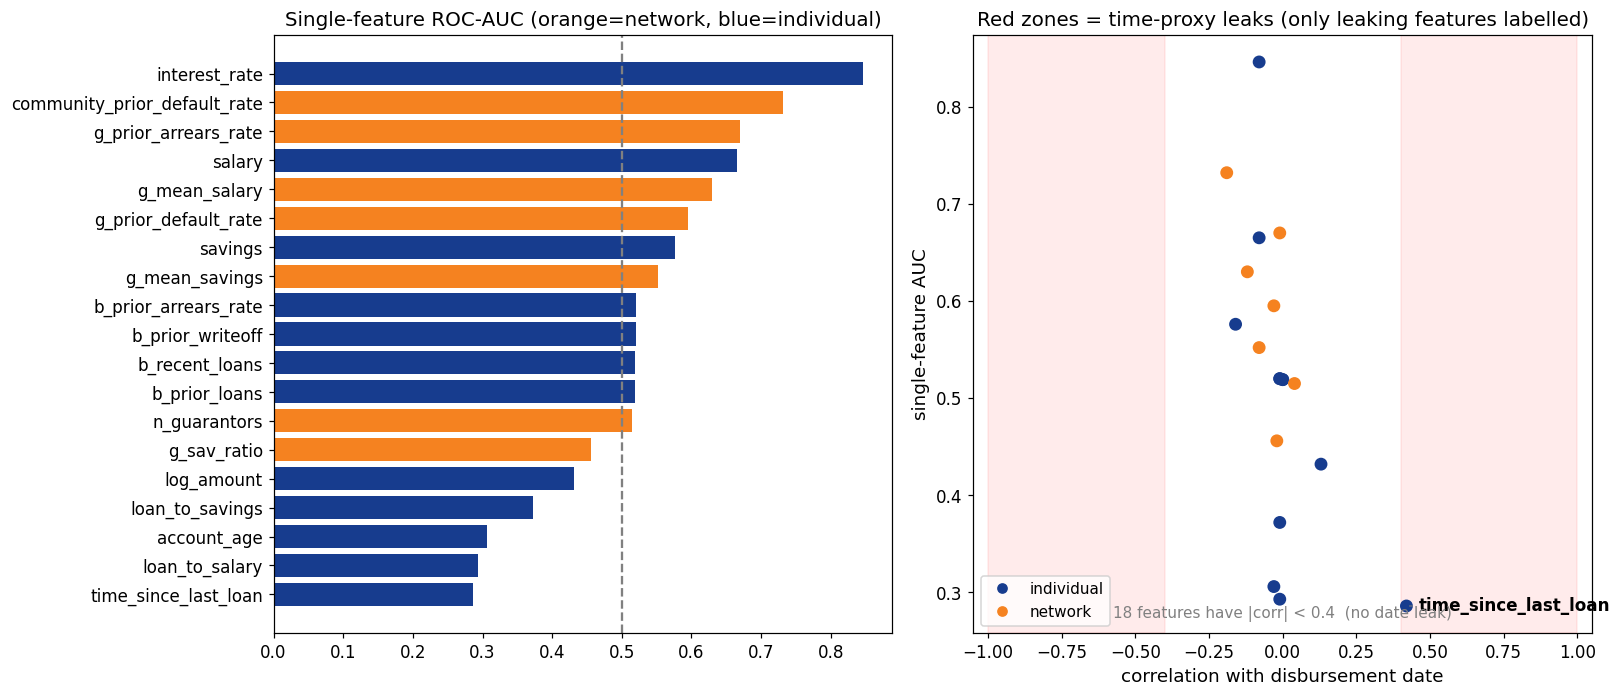

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
sc = screen.sort_values("single_auc")
colors = ["#F58220" if g=="network" else "#173C8E" for g in sc.group]
ax[0].barh(sc.feature, sc.single_auc, color=colors); ax[0].axvline(0.5, ls="--", c="grey")
ax[0].set_title("Single-feature ROC-AUC (orange=network, blue=individual)")

# Right panel = date-leak check. Only features that fall inside a red zone are labelled;
# the left panel already names every feature, so the cluster near 0 stays uncluttered.
pt_colors = ["#F58220" if g=="network" else "#173C8E" for g in screen.group]
ax[1].scatter(screen.date_corr, screen.single_auc, c=pt_colors, s=55, zorder=3)
ax[1].axvspan(-1, -0.4, color="red", alpha=0.08); ax[1].axvspan(0.4, 1, color="red", alpha=0.08)
leaks = screen[screen.date_corr.abs() >= 0.4]
for _, r in leaks.iterrows():
    ax[1].annotate(r.feature, (r.date_corr, r.single_auc),
                   xytext=(8, 0), textcoords="offset points", fontsize=11,
                   va="center", fontweight="bold",
                   arrowprops=dict(arrowstyle="-", color="grey", lw=0.7))
ax[1].text(0.0, 0.02, f"{len(screen) - len(leaks)} features have |corr| < 0.4  (no date leak)",
           transform=ax[1].get_xaxis_transform(), ha="center", va="bottom", fontsize=10, color="grey")
from matplotlib.lines import Line2D
ax[1].legend(handles=[Line2D([0], [0], marker="o", ls="", color="#173C8E", label="individual"),
                      Line2D([0], [0], marker="o", ls="", color="#F58220", label="network")],
             loc="lower left", fontsize=10)
ax[1].set_xlim(-1.05, 1.05)
ax[1].set_xlabel("correlation with disbursement date"); ax[1].set_ylabel("single-feature AUC")
ax[1].set_title("Red zones = time-proxy leaks (only leaking features labelled)")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"01_leakage_evidence.png", dpi=160); plt.show()

## class imbalance and feature spread

Defaults are rare (the **class imbalance** below), which is why we score with PR-AUC and handle
imbalance later. The other panels show how loan-to-savings and the interest rate separate good
from bad loans, and how the features relate to each other.

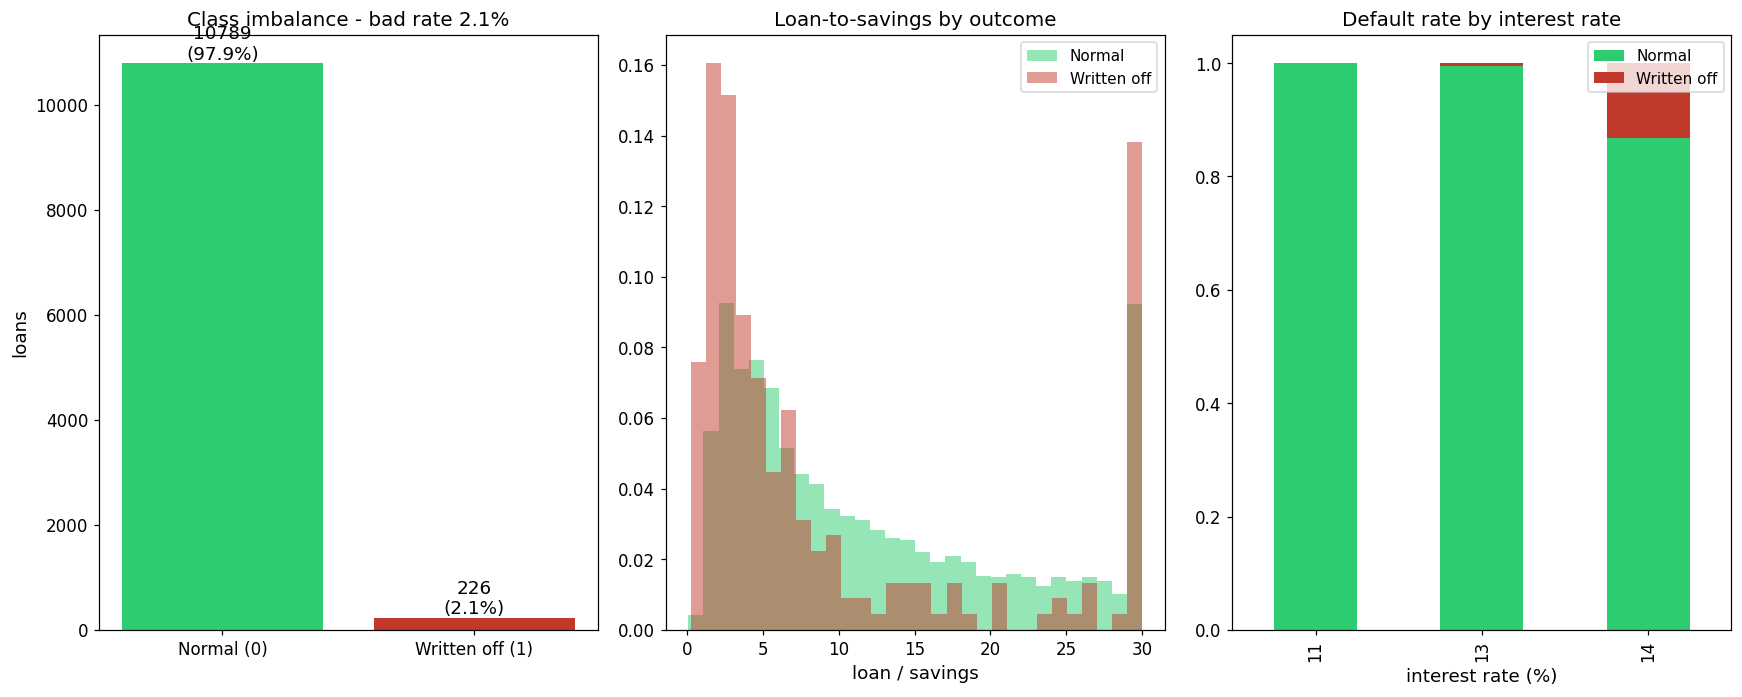

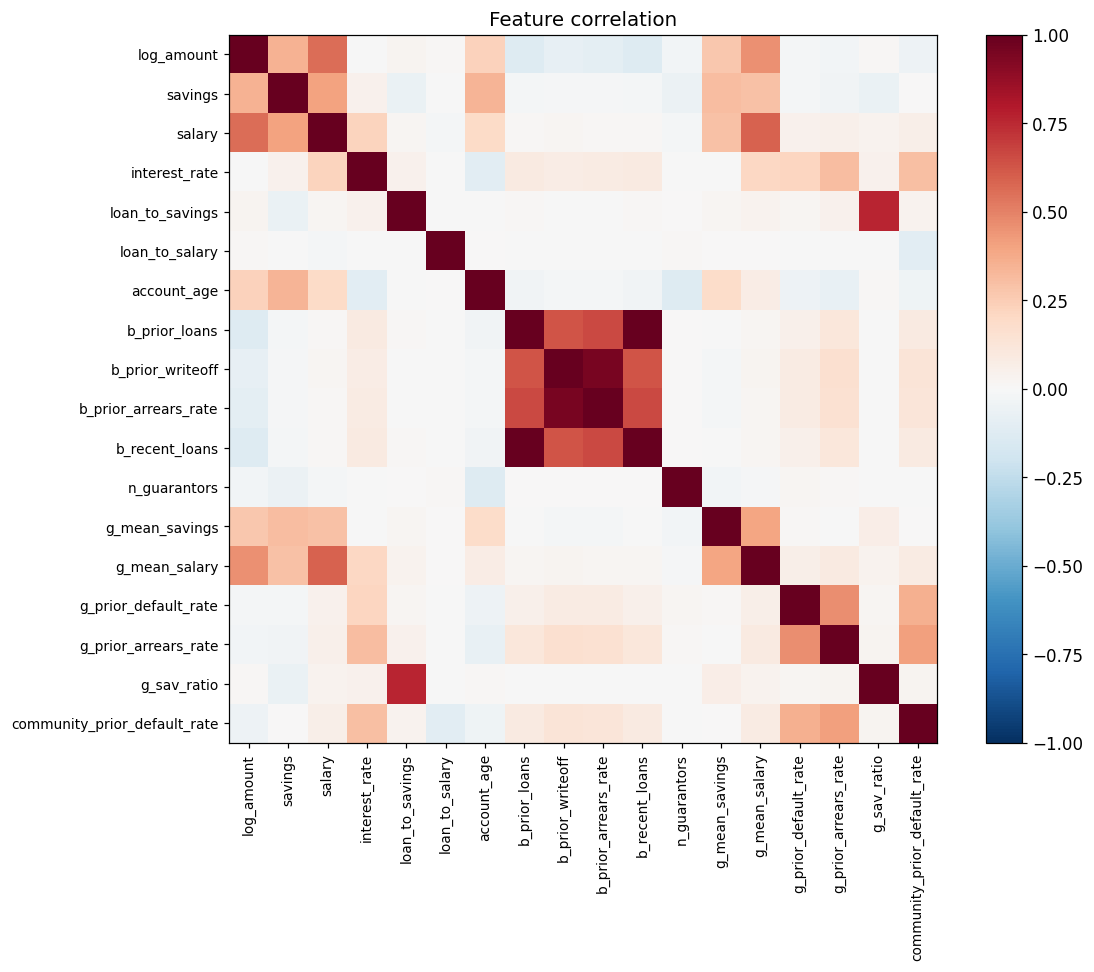

In [9]:
lab = cohort.label
fig, ax = plt.subplots(1, 3, figsize=(16, 6.5))
vc = lab.value_counts().sort_index()
ax[0].bar(["Normal (0)","Written off (1)"], vc.values, color=["#2ecc71","#c0392b"])
for i,v in enumerate(vc.values): ax[0].text(i, v, f"{v}\n({v/len(lab):.1%})", ha="center", va="bottom")
ax[0].set_title(f"Class imbalance - bad rate {lab.mean():.1%}"); ax[0].set_ylabel("loans")
for lv,c,nm in [(0,"#2ecc71","Normal"),(1,"#c0392b","Written off")]:
    ax[1].hist(cohort.loc[lab==lv,"loan_to_savings"].clip(upper=30), bins=30, alpha=0.5, color=c, label=nm, density=True)
ax[1].set_title("Loan-to-savings by outcome"); ax[1].set_xlabel("loan / savings"); ax[1].legend()
ct = pd.crosstab(cohort.interest_rate.round(), lab, normalize="index")
ct.plot(kind="bar", stacked=True, ax=ax[2], color=["#2ecc71","#c0392b"]); ax[2].set_title("Default rate by interest rate")
ax[2].set_xlabel("interest rate (%)"); ax[2].legend(["Normal","Written off"], fontsize=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"07_data_overview.png", dpi=160); plt.show()
print("class counts:"); print(lab.map({0:"Normal",1:"Written off"}).value_counts().to_string())

fig, axc = plt.subplots(figsize=(11, 9)); corr = cohort[FULL_FEATURES].corr()
im = axc.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axc.set_xticks(range(len(FULL_FEATURES))); axc.set_xticklabels(FULL_FEATURES, rotation=90, fontsize=9)
axc.set_yticks(range(len(FULL_FEATURES))); axc.set_yticklabels(FULL_FEATURES, fontsize=9)
plt.colorbar(im, fraction=0.046); axc.set_title("Feature correlation"); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"07_feature_correlation.png", dpi=160); plt.show()

### Feature by outcome
How each feature differs between written-off and normal loans (a quick view of which features separate the two).

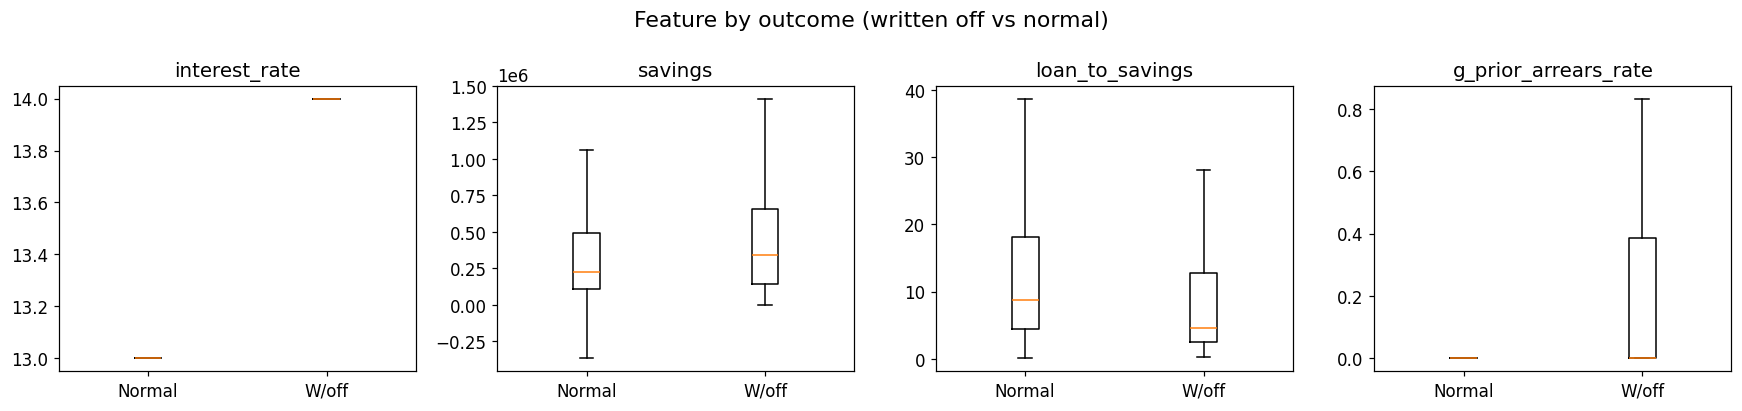

In [10]:
# Feature-by-outcome: how each feature differs between written-off and normal loans.
_biv = [c for c in ["interest_rate", "savings", "loan_to_savings", "g_prior_arrears_rate"] if c in df.columns]
fig, ax = plt.subplots(1, len(_biv), figsize=(4 * len(_biv), 3.8))
for a, c in zip(np.atleast_1d(ax), _biv):
    a.boxplot([df.loc[df.label == 0, c].dropna(), df.loc[df.label == 1, c].dropna()], showfliers=False)
    a.set_xticks([1, 2]); a.set_xticklabels(["Normal", "W/off"]); a.set_title(c)
plt.suptitle("Feature by outcome (written off vs normal)"); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"07c_bivariate.png", dpi=160); plt.show()

## Splitting the data fairly

A borrower can have several loans, so we keep each borrower entirely in train **or** test (never
both). Defaults are rare, so we judge models with **PR-AUC** (ranking the rare bad loans), not
plain accuracy.

In [11]:
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
y = cohort.label.values; groups = cohort.borrower.values
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tr_idx, te_idx = next(GroupShuffleSplit(1, test_size=0.25, random_state=RANDOM_STATE).split(cohort, y, groups))
train, test = cohort.iloc[tr_idx], cohort.iloc[te_idx]
print(f"hold-out: train={len(train)} (bad {train.label.sum()})  test={len(test)} (bad {test.label.sum()})")

## Training five model families with a RandomizedSearch experiment engine

Logistic regression, decision tree, random forest, XGBoost, and a **feed-forward neural network** (a
multi-layer perceptron: an input layer, one or two hidden layers, and an output layer, no recurrence). Instead of a fixed
grid, each model draws its settings from **ranges**, and we run `N_ITER` random experiments per model
(`RandomizedSearchCV`) - so the number of experiments is a knob, not a hard-coded list. Every model is run
twice - **borrower-only** and **borrower + network** - so the leaderboard shows directly whether the network helps.
Selection metric is **PR-AUC** (defaults are rare, so ranking the rare bad loans matters, not accuracy).

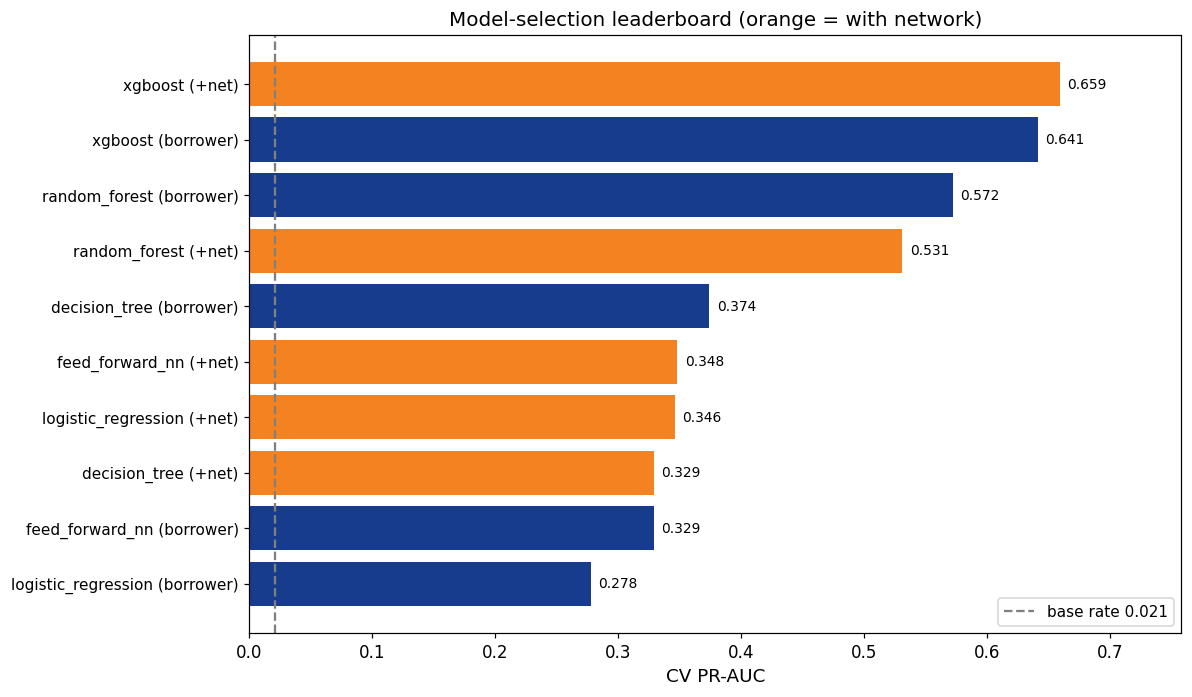

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from scipy.stats import loguniform, randint, uniform
import xgboost as xgb

N_ITER = 15   # experiments PER MODEL (a knob, not a fixed grid). Raise for a deeper search, lower for speed.
spw = float((y == 0).sum() / max(1, (y == 1).sum()))
def make(est, scale=False):
    steps = [("imp", SimpleImputer(strategy="median"))]
    if scale: steps.append(("sc", StandardScaler()))
    steps.append(("clf", est)); return Pipeline(steps)

# each model draws from RANGES (distributions) or small lists; RandomizedSearchCV samples N_ITER of them
SPECS = {
 "logistic_regression": (make(LogisticRegression(max_iter=3000), scale=True),
     {"clf__C": loguniform(1e-3, 1e2), "clf__class_weight": ["balanced", None]}),
 "decision_tree": (make(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
     {"clf__max_depth": randint(2, 10), "clf__min_samples_leaf": randint(5, 60)}),
 "random_forest": (make(RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
     {"clf__max_depth": [4, 6, 8, 12, None], "clf__min_samples_leaf": randint(3, 50), "clf__max_features": ["sqrt", "log2", None]}),
 "xgboost": (make(xgb.XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, tree_method="hist")),
     {"clf__n_estimators": randint(200, 600), "clf__max_depth": randint(2, 5), "clf__learning_rate": loguniform(0.02, 0.2),
      "clf__subsample": uniform(0.7, 0.3), "clf__colsample_bytree": uniform(0.7, 0.3), "clf__scale_pos_weight": [1, round(spw)]}),
 "feed_forward_nn": (make(MLPClassifier(max_iter=800, early_stopping=True, n_iter_no_change=20, random_state=RANDOM_STATE), scale=True),
     {"clf__hidden_layer_sizes": [(16,), (32,), (64,), (32, 16), (64, 32)], "clf__alpha": loguniform(1e-5, 1e-1)}),
}
FEATURE_SETS = {"borrower_only": IND_FEATURES, "borrower_plus_network": FULL_FEATURES}
SCORING = {"pr_auc": "average_precision", "roc_auc": "roc_auc", "f1": "f1",
           "precision": "precision", "recall": "recall", "accuracy": "accuracy"}
METRICS = list(SCORING.keys())

leaderboard, tuned, search_results = [], {}, {}
for fs_name, feats in FEATURE_SETS.items():
    for m_name, (pipe, dist) in SPECS.items():
        srch = RandomizedSearchCV(pipe, dist, n_iter=N_ITER, scoring=SCORING, refit="pr_auc",
                                  cv=cv, n_jobs=-1, random_state=RANDOM_STATE, error_score="raise")
        srch.fit(cohort[feats].values, y, groups=groups)
        bi = srch.best_index_
        tuned[(fs_name, m_name)] = (srch.best_estimator_, feats)
        cvr = pd.DataFrame(srch.cv_results_)
        keep = ["params"] + [f"mean_test_{k}" for k in METRICS] + ["std_test_pr_auc", "rank_test_pr_auc"]
        search_results[(fs_name, m_name)] = cvr[keep].sort_values("rank_test_pr_auc").reset_index(drop=True)
        leaderboard.append(dict(features=fs_name, model=m_name, settings_tried=len(cvr),
            cv_pr_auc=round(float(cvr.loc[bi, "mean_test_pr_auc"]), 3),
            roc_auc=round(float(cvr.loc[bi, "mean_test_roc_auc"]), 3),
            f1=round(float(cvr.loc[bi, "mean_test_f1"]), 3),
            precision=round(float(cvr.loc[bi, "mean_test_precision"]), 3),
            recall=round(float(cvr.loc[bi, "mean_test_recall"]), 3),
            accuracy=round(float(cvr.loc[bi, "mean_test_accuracy"]), 3),
            best_params=srch.best_params_))
lb = pd.DataFrame(leaderboard).sort_values("cv_pr_auc", ascending=False)
lb.to_csv(OUTPUT_DIR/"02_tuning_leaderboard.csv", index=False)
print(f"RandomizedSearchCV: {N_ITER} experiments/model x {len(FEATURE_SETS)} feature sets x 5-fold CV")
print("PR-AUC baseline (bad rate):", round(y.mean(), 3))
print(lb[["features","model","settings_tried","cv_pr_auc","roc_auc","f1","precision","recall","accuracy"]].to_string(index=False))

order = lb.sort_values("cv_pr_auc")
plt.figure(figsize=(11, 6.5))
plt.barh(range(len(order)), order.cv_pr_auc,
         color=["#F58220" if f == "borrower_plus_network" else "#173C8E" for f in order.features])
plt.yticks(range(len(order)), (order.model + " (" + order.features.str.replace("borrower_plus_network", "+net").str.replace("borrower_only", "borrower") + ")"), fontsize=10)
for i, v in enumerate(order.cv_pr_auc): plt.text(v + 0.006, i, f"{v:.3f}", va="center", fontsize=9)
plt.axvline(y.mean(), ls="--", c="grey", label=f"base rate {y.mean():.3f}")
plt.xlim(0, max(order.cv_pr_auc) * 1.15)
plt.xlabel("CV PR-AUC"); plt.title("Model-selection leaderboard (orange = with network)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.savefig(OUTPUT_DIR/"02_leaderboard.png", dpi=160); plt.show()

## Imbalance handling; generating minority data (SMOTE) vs class weighting

Defaults are rare, so we **generate synthetic defaults** with SMOTE and three variants, plus
undersampling, and compare to plain class weighting. We keep whichever wins on PR-AUC.

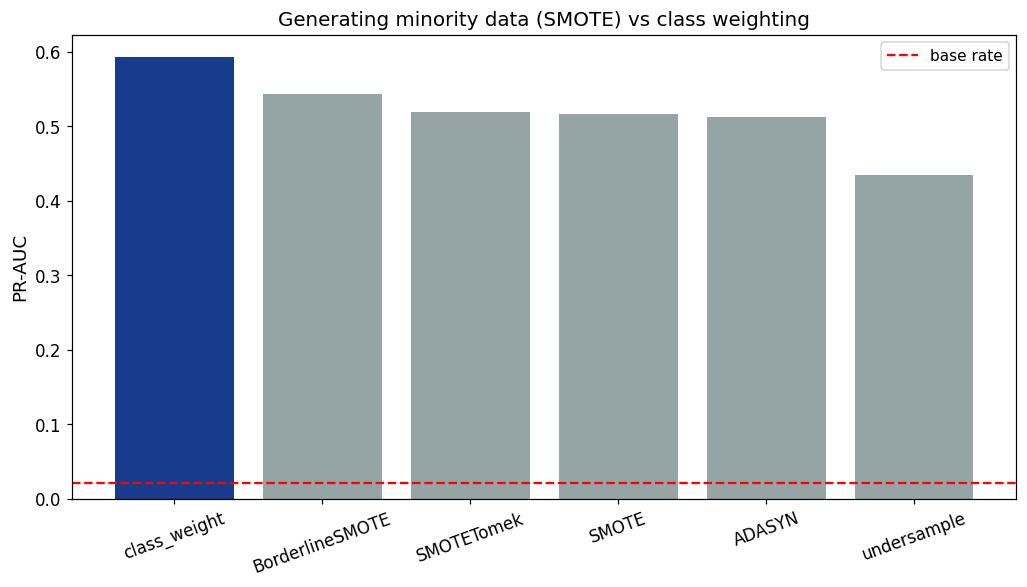

In [13]:
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import average_precision_score

def xgb_pipe(sampler=None):
    steps = [("imp", SimpleImputer(strategy="median"))]
    if sampler is not None: steps.append(("res", sampler))
    kw = {} if sampler is not None else {"scale_pos_weight": spw}
    steps.append(("clf", xgb.XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                  random_state=RANDOM_STATE, tree_method="hist", **kw)))
    return Pipeline(steps)

strategies = [("class_weight", None), ("SMOTE", SMOTE(random_state=RANDOM_STATE)),
              ("BorderlineSMOTE", BorderlineSMOTE(random_state=RANDOM_STATE)),
              ("ADASYN", ADASYN(random_state=RANDOM_STATE)),
              ("SMOTETomek", SMOTETomek(random_state=RANDOM_STATE)),
              ("undersample", RandomUnderSampler(random_state=RANDOM_STATE))]
imb_rows = []
for name, sampler in strategies:
    p = cross_val_predict(xgb_pipe(sampler), cohort[FULL_FEATURES].values, y, cv=cv, groups=groups, method="predict_proba")[:,1]
    imb_rows.append(dict(strategy=name, pr_auc=round(average_precision_score(y,p),3), roc_auc=round(roc_auc_score(y,p),3)))
imb_df = pd.DataFrame(imb_rows).sort_values("pr_auc", ascending=False)
imb_df.to_csv(OUTPUT_DIR/"02b_imbalance_comparison.csv", index=False); print(imb_df.to_string(index=False))
plt.figure(figsize=(9.5, 5.5))
plt.bar(imb_df.strategy, imb_df.pr_auc, color=["#173C8E" if s=="class_weight" else "#95a5a6" for s in imb_df.strategy])
plt.axhline(y.mean(), ls="--", c="red", label="base rate"); plt.ylabel("PR-AUC"); plt.legend()
plt.title("Generating minority data (SMOTE) vs class weighting"); plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"02b_imbalance.png", dpi=160); plt.show()
print("\n-> We generated synthetic defaults with SMOTE + 3 variants; none beat class weighting on PR-AUC.")
print("   Literature agrees: oversampling mainly helps weak learners and harms calibration, and our")
print("   model is a strong, calibrated tree. (Elor & Averbuch 2022; van den Goorbergh JAMIA 2022.)")

## Tuning the class-weighting hyperparameter (scale_pos_weight)

The usual rule is `scale_pos_weight = neg/pos` (~48 here). But that heuristic targets balanced accuracy at a 0.5 threshold, not ranking. For our headline metric (PR-AUC) heavy up-weighting distorts the probabilities and hurts ranking; the recall we want comes from the **threshold**, not from re-weighting. We sweep it on borrower-grouped out-of-fold PR-AUC and let the evidence choose. `[cite: Brownlee, Weighted XGBoost for Class Imbalance; Elor & Averbuch-Elor, 2022]`

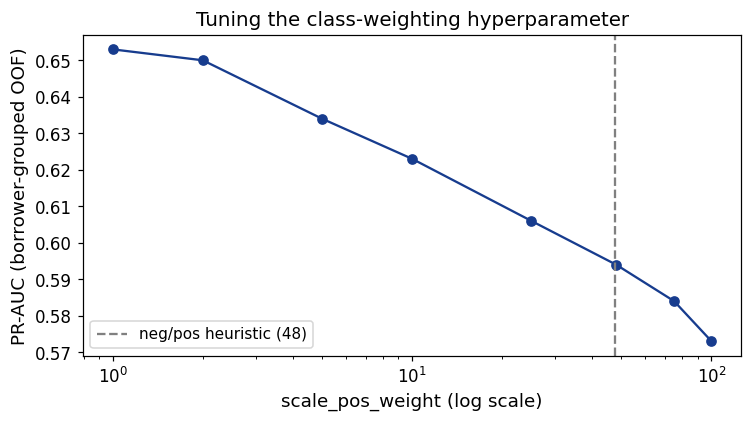

In [14]:
from sklearn.metrics import precision_recall_curve, f1_score
_neg, _pos = int((y == 0).sum()), int((y == 1).sum()); _default = _neg / _pos
def _oof_spw(w):
    p = Pipeline([("imp", SimpleImputer(strategy="median")),
        ("clf", xgb.XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, scale_pos_weight=w, eval_metric="logloss",
            random_state=RANDOM_STATE, tree_method="hist"))])
    return cross_val_predict(p, cohort[FULL_FEATURES].values, y, cv=cv, groups=groups, method="predict_proba")[:, 1]

_grid = sorted({1, 2, 5, 10, 25, round(_default), 75, 100})
_rows = []
for w in _grid:
    pp = _oof_spw(w); ap = average_precision_score(y, pp)
    prec, rec, thr = precision_recall_curve(y, pp)
    bf1 = max(f1_score(y, (pp >= t).astype(int), zero_division=0) for t in thr)
    _rows.append({"scale_pos_weight": w, "pr_auc": round(ap, 3), "roc_auc": round(roc_auc_score(y, pp), 3),
                  "best_f1": round(bf1, 3), "note": "neg/pos heuristic" if abs(w - round(_default)) < 1 else ""})
spw_tab = pd.DataFrame(_rows); spw_tab.to_csv(OUTPUT_DIR / "02c_scale_pos_weight.csv", index=False)
print(f"default scale_pos_weight (neg/pos) = {_default:.1f}")
print(spw_tab.to_string(index=False))
SPW_BEST = int(spw_tab.sort_values("pr_auc", ascending=False).iloc[0]["scale_pos_weight"])
print(f"\n-> best PR-AUC at scale_pos_weight = {SPW_BEST}. The neg/pos heuristic ({_default:.0f}) over-weights the")
print("   minority and lowers PR-AUC; less re-weighting ranks better, and the operating threshold gives the recall.")

plt.figure(figsize=(7, 4))
plt.plot(spw_tab.scale_pos_weight, spw_tab.pr_auc, "o-", color="#173C8E")
plt.axvline(_default, ls="--", c="grey", label=f"neg/pos heuristic ({_default:.0f})")
plt.xscale("log"); plt.xlabel("scale_pos_weight (log scale)"); plt.ylabel("PR-AUC (borrower-grouped OOF)")
plt.title("Tuning the class-weighting hyperparameter"); plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02c_scale_pos_weight.png", dpi=160); plt.show()

spw = SPW_BEST   # adopt the tuned class weight for the deployed model and the rest of the notebook
print(f"\nAdopted scale_pos_weight = {spw} for the deployed model (down from the neg/pos heuristic {_default:.0f}).")

## Choosing the best model

We open up the grid search: the full list of settings per model (best first), then the best of
each model type and experiment, then the overall winner.

In [15]:
try:
    from IPython.display import display; HAVE_IPY = True
except Exception:
    HAVE_IPY = False

REN = {"mean_test_pr_auc":"pr_auc","mean_test_roc_auc":"roc_auc","mean_test_f1":"f1",
       "mean_test_precision":"precision","mean_test_recall":"recall","mean_test_accuracy":"accuracy",
       "std_test_pr_auc":"std_pr","rank_test_pr_auc":"rank"}
MCOLS = ["pr_auc","roc_auc","f1","precision","recall","accuracy","std_pr"]

for m_name in SPECS:
    res = search_results[("borrower_plus_network", m_name)].copy()
    params = pd.DataFrame(list(res["params"])); params.columns = [c.replace("clf__","") for c in params.columns]
    metrics = res.drop(columns=["params"]).rename(columns=REN).reset_index(drop=True)
    tbl = pd.concat([params.reset_index(drop=True), metrics], axis=1)
    for c in MCOLS:
        if c in tbl: tbl[c] = tbl[c].astype(float).round(3)
    tbl = tbl.sort_values("rank").reset_index(drop=True)
    tbl.to_csv(OUTPUT_DIR/f"02_grid_{m_name}.csv", index=False)
    print(f"\n=== {m_name}: all {len(tbl)} experiments - full metrics, best (rank 1) row highlighted ===")
    shown = False
    if HAVE_IPY:
        try:
            sty = (tbl.style
                     .highlight_max(subset=["pr_auc"], color="#8ef0a6")
                     .format({c:"{:.3f}" for c in MCOLS if c in tbl})
                     .hide(axis="index"))
            display(sty); shown = True
        except Exception:
            shown = False
    if not shown:
        show = tbl.copy(); show.insert(0, "best", np.where(show["rank"]==1, "*** BEST", ""))
        print(show.to_string(index=False))

best_per = (pd.DataFrame(leaderboard).sort_values("cv_pr_auc", ascending=False)
            .groupby("model", as_index=False).first().sort_values("cv_pr_auc", ascending=False))
best_per.to_csv(OUTPUT_DIR/"02_best_per_model.csv", index=False)
print("\n=== BEST SETTING PER MODEL FAMILY (full metrics) ===")
print(best_per[["model","features","cv_pr_auc","roc_auc","f1","precision","recall","accuracy","best_params"]].to_string(index=False))
win = best_per.iloc[0]
print(f"\n>>> BEST FAMILY: {win['model']} (CV PR-AUC {win['cv_pr_auc']}, F1 {win['f1']}, ROC {win['roc_auc']}). We deploy the +network XGBoost.")

C,class_weight,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
0.046617,None,0.346,0.893,0.216,0.570,0.137,0.980,0.079,1
0.008261,None,0.344,0.896,0.165,0.577,0.101,0.980,0.074,2
0.008264,None,0.344,0.896,0.165,0.577,0.101,0.980,0.074,3
3.470267,None,0.343,0.891,0.207,0.552,0.131,0.980,0.087,4
14.528247,None,0.343,0.891,0.207,0.552,0.131,0.980,0.087,5
0.004983,None,0.341,0.895,0.162,0.611,0.097,0.980,0.073,6
0.001952,None,0.327,0.892,0.143,0.626,0.083,0.980,0.069,7
0.001915,None,0.327,0.892,0.143,0.626,0.083,0.980,0.069,8
0.001009,None,0.317,0.889,0.114,0.518,0.065,0.980,0.069,9
1.143578,balanced,0.304,0.902,0.221,0.129,0.802,0.885,0.076,10


max_depth,min_samples_leaf,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
8,23,0.329,0.852,0.214,0.125,0.777,0.885,0.057,1
9,28,0.313,0.865,0.219,0.129,0.773,0.887,0.040,2
8,15,0.302,0.852,0.215,0.126,0.777,0.886,0.054,3
7,42,0.272,0.864,0.195,0.111,0.815,0.864,0.053,4
6,19,0.271,0.890,0.220,0.128,0.836,0.879,0.066,5
9,48,0.267,0.874,0.216,0.125,0.810,0.880,0.042,6
6,40,0.267,0.867,0.204,0.117,0.827,0.869,0.070,7
6,25,0.265,0.880,0.215,0.125,0.825,0.877,0.064,8
8,56,0.250,0.873,0.204,0.117,0.818,0.870,0.042,9
6,6,0.216,0.884,0.221,0.129,0.829,0.880,0.063,10


max_depth,max_features,min_samples_leaf,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
nan,None,9,0.531,0.945,0.503,0.460,0.568,0.978,0.099,1
nan,None,24,0.501,0.942,0.373,0.259,0.692,0.953,0.091,2
8.000000,None,26,0.480,0.940,0.314,0.204,0.724,0.935,0.089,3
8.000000,None,44,0.463,0.937,0.288,0.181,0.744,0.925,0.080,4
12.000000,None,49,0.461,0.936,0.275,0.170,0.744,0.920,0.079,5
12.000000,sqrt,17,0.450,0.948,0.370,0.264,0.661,0.954,0.061,6
nan,log2,26,0.441,0.945,0.322,0.215,0.699,0.940,0.079,7
12.000000,log2,24,0.441,0.945,0.324,0.217,0.687,0.941,0.073,8
8.000000,sqrt,23,0.441,0.945,0.326,0.215,0.715,0.939,0.070,9
nan,sqrt,29,0.440,0.945,0.315,0.205,0.721,0.936,0.073,10


colsample_bytree,learning_rate,max_depth,n_estimators,scale_pos_weight,subsample,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
0.797599,0.048945,3,566,1,0.876025,0.659,0.951,0.627,0.910,0.479,0.988,0.066,1
0.833750,0.025177,4,287,1,0.880335,0.653,0.958,0.561,0.900,0.409,0.987,0.057,2
0.877724,0.022258,4,334,1,0.835150,0.653,0.958,0.581,0.897,0.431,0.987,0.068,3
0.989577,0.080922,2,240,1,0.940659,0.650,0.951,0.602,0.893,0.456,0.988,0.071,4
0.729302,0.096664,4,463,1,0.752009,0.630,0.948,0.589,0.877,0.444,0.987,0.062,5
0.812362,0.178544,4,271,1,0.879055,0.628,0.943,0.575,0.823,0.442,0.987,0.068,6
0.706919,0.066958,4,369,48,0.787643,0.624,0.949,0.571,0.564,0.590,0.982,0.050,7
0.703979,0.175078,3,441,48,0.791384,0.619,0.943,0.598,0.626,0.580,0.984,0.053,8
0.977998,0.106734,4,414,48,0.713568,0.615,0.941,0.602,0.663,0.553,0.985,0.057,9
0.809909,0.057161,4,250,48,0.854270,0.611,0.948,0.482,0.393,0.635,0.973,0.062,10


alpha,hidden_layer_sizes,pr_auc,roc_auc,f1,precision,recall,accuracy,std_pr,rank
0.000687,"(64, 32)",0.348,0.886,0.238,0.659,0.151,0.981,0.063,1
0.002538,"(64,)",0.336,0.851,0.239,0.693,0.153,0.981,0.078,2
0.000042,"(64,)",0.336,0.851,0.239,0.693,0.153,0.981,0.078,3
0.000292,"(64,)",0.336,0.851,0.239,0.693,0.153,0.981,0.078,4
0.000012,"(64,)",0.336,0.851,0.239,0.693,0.153,0.981,0.078,5
0.000315,"(64, 32)",0.330,0.875,0.253,0.728,0.159,0.981,0.056,6
0.000054,"(64, 32)",0.330,0.875,0.246,0.719,0.154,0.981,0.056,7
0.000053,"(64, 32)",0.330,0.875,0.245,0.708,0.154,0.981,0.056,8
0.000015,"(32, 16)",0.306,0.794,0.220,0.498,0.144,0.981,0.153,9
0.001256,"(32, 16)",0.219,0.710,0.174,0.342,0.117,0.980,0.160,10


### Each model up close: confusion matrix + learning curve

For every family (with the network), its **confusion matrix** at the >=80%-recall operating point and a
**learning curve** (does it keep improving with more data?). The **loss curves** for XGBoost and the neural
net - the classic per-round / per-epoch views - are in the next section.

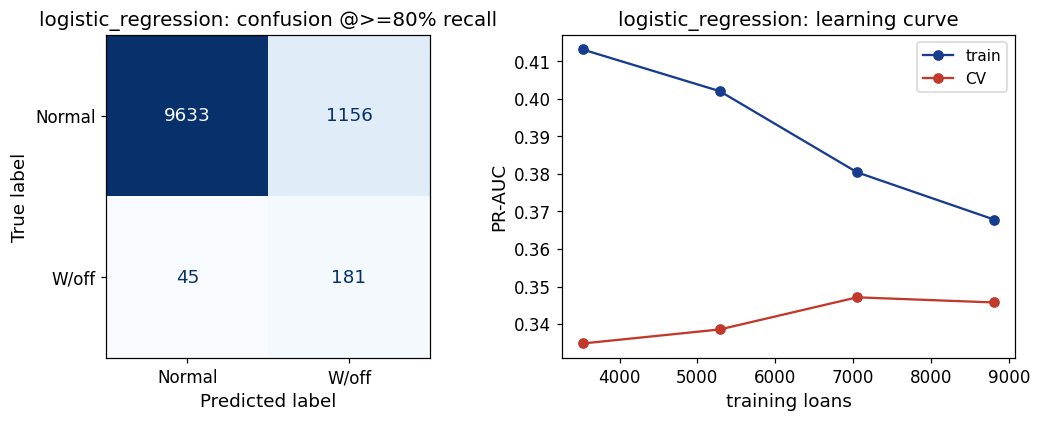

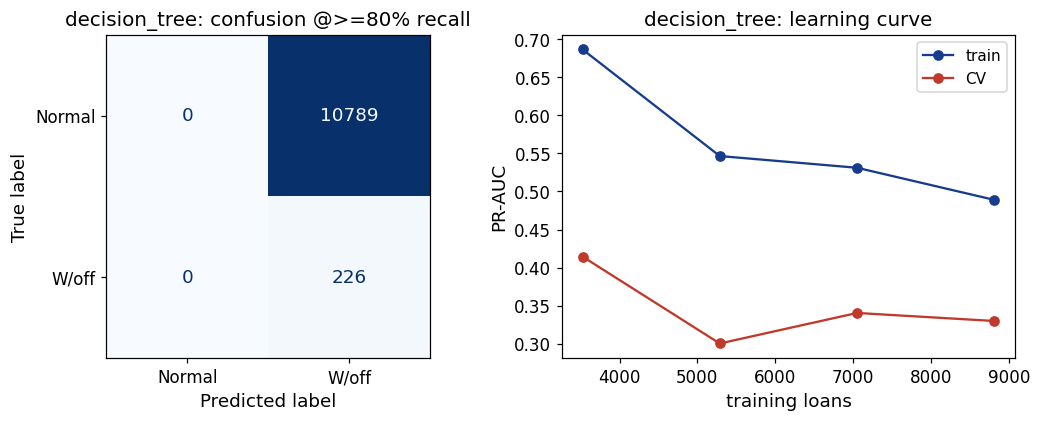

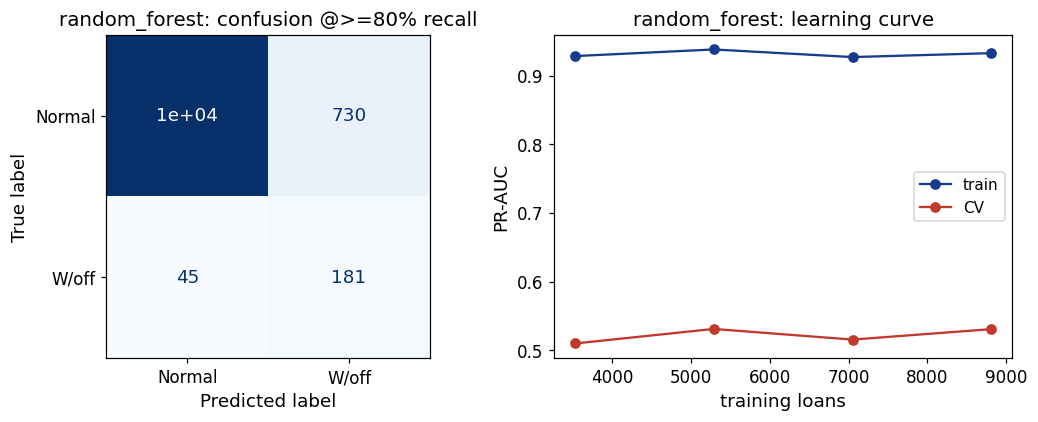

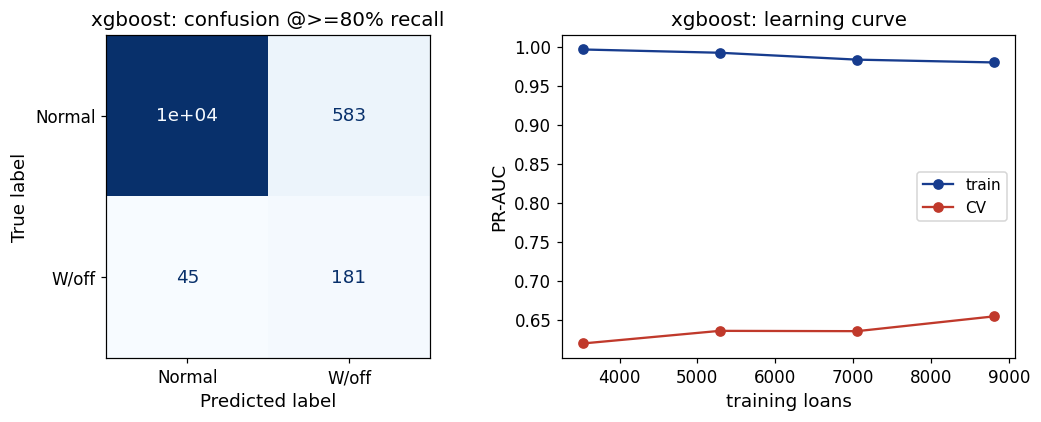

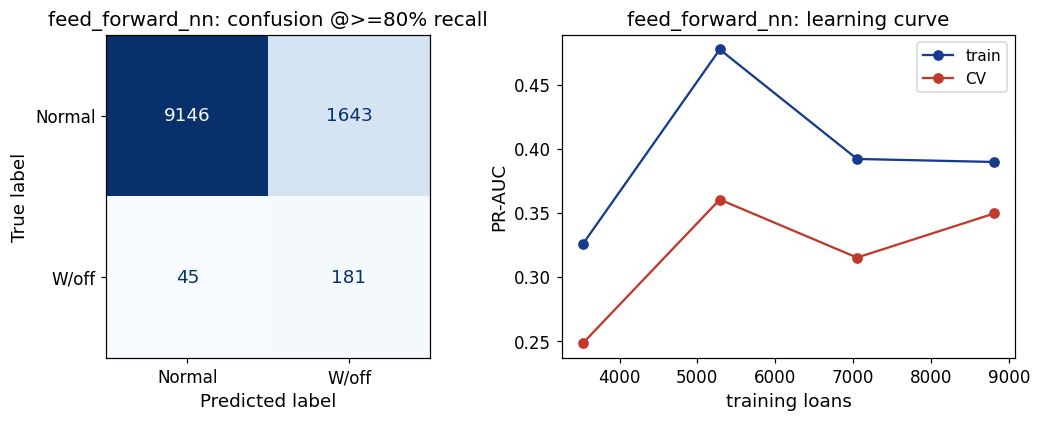

In [16]:
# Per-model diagnostics: confusion matrix (@>=80% recall) + learning curve for each family.
from sklearn.model_selection import cross_val_predict, learning_curve
from sklearn.metrics import confusion_matrix, precision_recall_curve, ConfusionMatrixDisplay, average_precision_score, precision_score

def _thr_recall(yt, s, t=TARGET_RECALL):
    pr, rc, th = precision_recall_curve(yt, s); ok = np.where(rc[:-1] >= t)[0]
    return float(th[ok[-1]]) if len(ok) else 0.5

for m_name in SPECS:
    est, feats = tuned[("borrower_plus_network", m_name)]
    p = cross_val_predict(est, cohort[feats].values, y, cv=cv, groups=groups, method="predict_proba")[:, 1]
    th = _thr_recall(y, p); pred = (p >= th).astype(int); cm = confusion_matrix(y, pred)
    sizes, tr_sc, va_sc = learning_curve(est, cohort[feats].values, y, groups=groups, cv=cv,
        scoring="average_precision", train_sizes=np.linspace(0.4, 1.0, 4), n_jobs=-1, error_score="raise")
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "W/off"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
    ax[0].set_title(f"{m_name}: confusion @>={TARGET_RECALL:.0%} recall")
    ax[1].plot(sizes, tr_sc.mean(1), "o-", label="train", color="#173C8E")
    ax[1].plot(sizes, va_sc.mean(1), "o-", label="CV", color="#c0392b")
    ax[1].set_title(f"{m_name}: learning curve"); ax[1].set_xlabel("training loans"); ax[1].set_ylabel("PR-AUC"); ax[1].legend()
    plt.tight_layout(); plt.savefig(OUTPUT_DIR/f"02d_diag_{m_name}.png", dpi=150); plt.show()
    prec = precision_score(y, pred, zero_division=0)
    print(f"{m_name:20s} PR-AUC {average_precision_score(y, p):.3f} | @>={TARGET_RECALL:.0%} recall precision {prec:.3f}, caught {cm[1,1]}/{cm[1,0]+cm[1,1]} write-offs")

## Training and loss curves
Do the models converge, are they overfitting, and would more data help? Three views: XGBoost log-loss per boosting round (train vs validation), the neural net's training loss per epoch, and cross-validated PR-AUC as the training set grows.

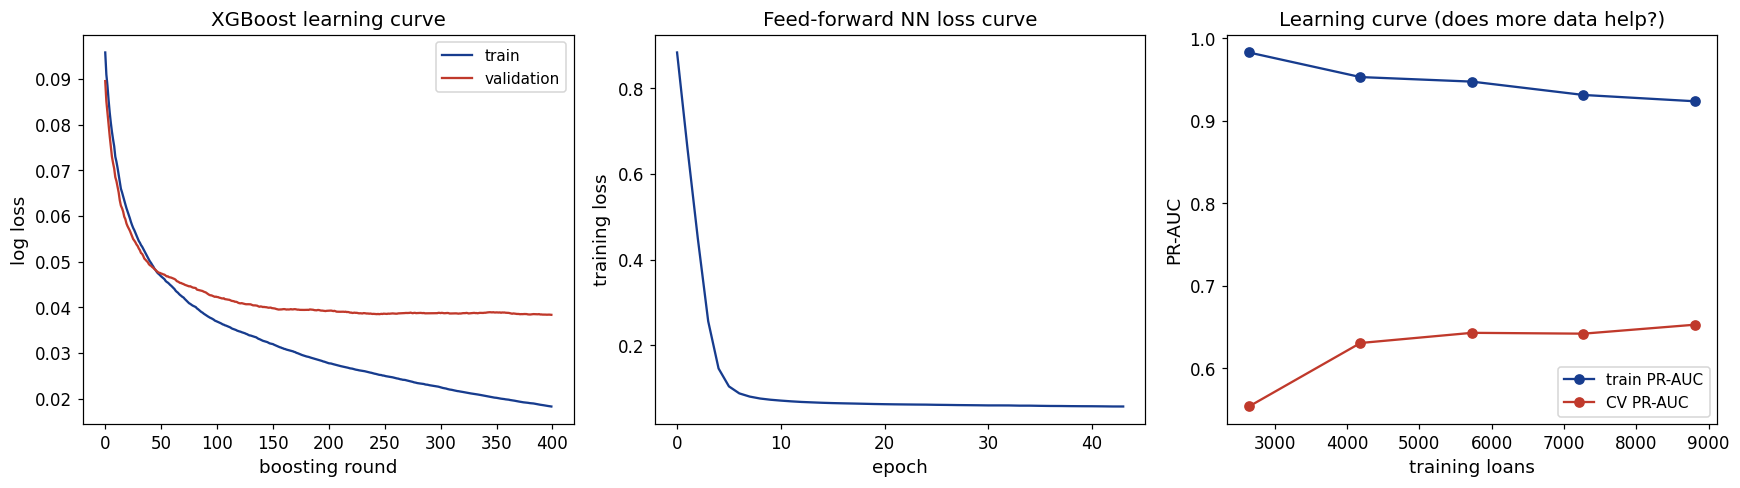

In [17]:
# Training and loss curves: convergence, over-fitting, and whether more data would help.
from sklearn.model_selection import GroupShuffleSplit, learning_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# one grouped train/validation split for the per-round / per-epoch curves
_gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
_tr, _va = next(_gss.split(cohort, y, groups))
_Xtr, _Xva = cohort.iloc[_tr][FULL_FEATURES], cohort.iloc[_va][FULL_FEATURES]
_ytr, _yva = y[_tr], y[_va]
_imp = SimpleImputer(strategy="median").fit(_Xtr)
_Xtr_i, _Xva_i = _imp.transform(_Xtr), _imp.transform(_Xva)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

# (1) XGBoost learning curve: log-loss per boosting round on train vs validation
_xgb = xgb.XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
    eval_metric="logloss", random_state=RANDOM_STATE, tree_method="hist")
_xgb.fit(_Xtr_i, _ytr, eval_set=[(_Xtr_i, _ytr), (_Xva_i, _yva)], verbose=False)
_ev = _xgb.evals_result()
ax[0].plot(_ev["validation_0"]["logloss"], label="train", color="#173C8E")
ax[0].plot(_ev["validation_1"]["logloss"], label="validation", color="#c0392b")
ax[0].set_title("XGBoost learning curve"); ax[0].set_xlabel("boosting round")
ax[0].set_ylabel("log loss"); ax[0].legend()

# (2) Feed-forward NN loss curve: training loss per epoch (the classic loss curve)
_sc = StandardScaler().fit(_Xtr_i)
_mlp = MLPClassifier(hidden_layer_sizes=(32, 16), alpha=1e-3, max_iter=400,
    early_stopping=True, n_iter_no_change=20, random_state=RANDOM_STATE)
_mlp.fit(_sc.transform(_Xtr_i), _ytr)
ax[1].plot(_mlp.loss_curve_, color="#173C8E")
ax[1].set_title("Feed-forward NN loss curve"); ax[1].set_xlabel("epoch")
ax[1].set_ylabel("training loss")

# (3) Learning curve vs training-set size: does more data help? (train vs CV gap)
_lc_pipe = ImbPipeline([("imp", SimpleImputer(strategy="median")),
    ("clf", xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
        eval_metric="logloss", random_state=RANDOM_STATE, tree_method="hist"))])
_sizes, _tr_sc, _va_sc = learning_curve(_lc_pipe, cohort[FULL_FEATURES].values, y,
    groups=groups, cv=cv, scoring="average_precision",
    train_sizes=np.linspace(0.3, 1.0, 5), n_jobs=-1, error_score="raise")
ax[2].plot(_sizes, _tr_sc.mean(1), "o-", label="train PR-AUC", color="#173C8E")
ax[2].plot(_sizes, _va_sc.mean(1), "o-", label="CV PR-AUC", color="#c0392b")
ax[2].set_title("Learning curve (does more data help?)"); ax[2].set_xlabel("training loans")
ax[2].set_ylabel("PR-AUC"); ax[2].legend()

plt.tight_layout(); plt.savefig(OUTPUT_DIR / "09b_learning_curves.png", dpi=160, bbox_inches="tight"); plt.show()

_gap = _ev["validation_1"]["logloss"][-1] - _ev["validation_0"]["logloss"][-1]
print(f"XGBoost final log-loss: train {_ev['validation_0']['logloss'][-1]:.3f}, "
      f"validation {_ev['validation_1']['logloss'][-1]:.3f} (gap {_gap:.3f}; small gap = not over-fitting)")
print(f"Neural net converged in {len(_mlp.loss_curve_)} epochs; final training loss {_mlp.loss_curve_[-1]:.3f}")
print(f"Learning curve: CV PR-AUC rises from {_va_sc.mean(1)[0]:.3f} (30% of data) to "
      f"{_va_sc.mean(1)[-1]:.3f} (all data); still rising = more data would help")

## Does the guarantor network help?

Three models on the same data: borrower-only, network-only, and both. If network-only beats the
base rate, the network carries real signal. The bootstrap gives a range on the *extra* lift from
adding the network.

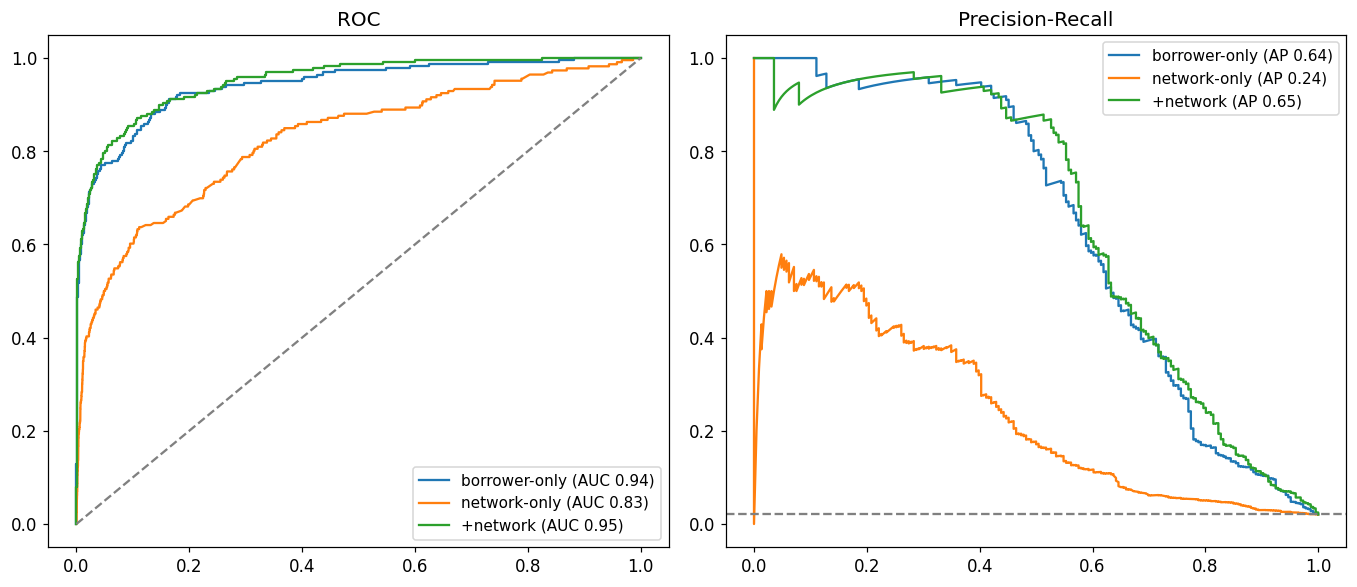

In [18]:
def oof(feats):
    p = np.zeros(len(cohort))
    for tr, te in cv.split(cohort[feats].values, y, groups):
        m = xgb_pipe(None); m.fit(cohort[feats].values[tr], y[tr]); p[te] = m.predict_proba(cohort[feats].values[te])[:,1]
    return p
p_ind, p_net, p_full = oof(IND_FEATURES), oof(NET_FEATURES), oof(FULL_FEATURES)
def rr(p): return (round(average_precision_score(y,p),3), round(roc_auc_score(y,p),3))
net_tab = pd.DataFrame([
    {"model":"baseline (bad rate)","pr_auc":round(y.mean(),3),"roc_auc":0.5},
    {"model":"borrower_only","pr_auc":rr(p_ind)[0],"roc_auc":rr(p_ind)[1]},
    {"model":"network_only","pr_auc":rr(p_net)[0],"roc_auc":rr(p_net)[1]},
    {"model":"borrower_plus_network","pr_auc":rr(p_full)[0],"roc_auc":rr(p_full)[1]}])
net_tab.to_csv(OUTPUT_DIR/"05_network_contribution.csv", index=False)
print("network contribution:"); print(net_tab.to_string(index=False))

from sklearn.metrics import roc_curve, precision_recall_curve as _prc
fig, ax = plt.subplots(1, 2, figsize=(12.5, 5.5))
for nm, p in [("borrower-only",p_ind),("network-only",p_net),("+network",p_full)]:
    fpr,tpr,_ = roc_curve(y,p); ax[0].plot(fpr,tpr,label=f"{nm} (AUC {roc_auc_score(y,p):.2f})")
    pr,rc,_ = _prc(y,p); ax[1].plot(rc,pr,label=f"{nm} (AP {average_precision_score(y,p):.2f})")
ax[0].plot([0,1],[0,1],"--",c="grey"); ax[0].set_title("ROC"); ax[0].legend(fontsize=10)
ax[1].axhline(y.mean(),ls="--",c="grey"); ax[1].set_title("Precision-Recall"); ax[1].legend(fontsize=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"05_roc_pr_curves.png", dpi=160); plt.show()

rng = np.random.RandomState(RANDOM_STATE); diffs = []
for _ in range(2000):
    idx = rng.randint(0, len(y), len(y))
    if y[idx].sum() == 0: continue
    diffs.append(average_precision_score(y[idx],p_full[idx]) - average_precision_score(y[idx],p_ind[idx]))
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"\nnetwork PR-AUC lift: {np.mean(diffs):+.3f}  95% CI [{lo:+.3f},{hi:+.3f}] -> "
      f"{'significant' if lo>0 else 'positive but not significant (homophily: risky borrowers cluster with risky guarantors)'}")
print(f"ROC-AUC borrower-only {rr(p_ind)[1]} -> +network {rr(p_full)[1]} (the network improves ranking)")

### Best model (XGBoost): borrower-only vs network-only vs borrower + network

The winning family, on the same data, with each feature set: a metrics table (PR-AUC, ROC-AUC, and
precision / recall / F1 at the >=80%-recall operating point) and the **confusion matrix of the borrower +
network model** (the one that is deployed).

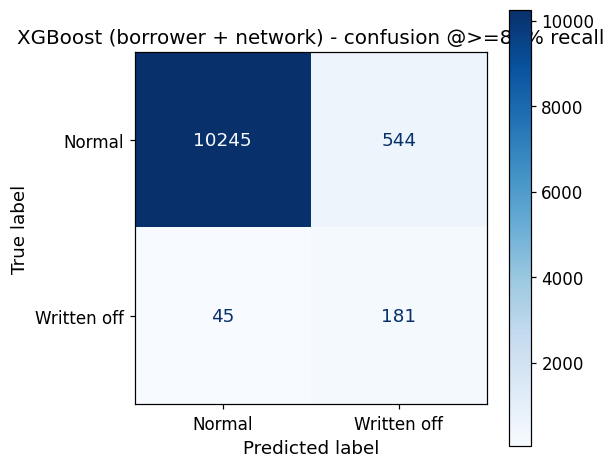

In [19]:
# Best model (XGBoost) across the three feature sets + the borrower+network confusion matrix.
from sklearn.metrics import (precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

def _metrics_at_recall(p, t=TARGET_RECALL):
    pr, rc, th = precision_recall_curve(y, p); ok = np.where(rc[:-1] >= t)[0]
    thr = float(th[ok[-1]]) if len(ok) else 0.5
    pred = (p >= thr).astype(int)
    return (dict(pr_auc=round(average_precision_score(y, p), 3), roc_auc=round(roc_auc_score(y, p), 3),
                 precision=round(precision_score(y, pred, zero_division=0), 3),
                 recall=round(recall_score(y, pred), 3), f1=round(f1_score(y, pred, zero_division=0), 3)), pred)

_sets = {"borrower_only": p_ind, "network_only": p_net, "borrower_plus_network": p_full}
_rows = []
for name, p in _sets.items():
    m, _ = _metrics_at_recall(p); _rows.append({"feature_set": name, **m})
best_cmp = pd.DataFrame(_rows)
best_cmp.to_csv(OUTPUT_DIR/"05b_xgb_featureset_metrics.csv", index=False)
print("XGBoost - feature-set comparison (PR-AUC/ROC-AUC, and precision/recall/F1 at >=80% recall):")
print(best_cmp.to_string(index=False))

_, pred_full = _metrics_at_recall(p_full); cm = confusion_matrix(y, pred_full)
fig, ax = plt.subplots(figsize=(5.6, 4.8))
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Written off"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("XGBoost (borrower + network) - confusion @>=80% recall")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"05b_xgb_confusion.png", dpi=160); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"\nborrower+network caught {tp}/{tp+fn} write-offs with {fp} false alarms at >=80% recall.")

## Did we under-engineer the network? (robustness check)

The incremental network lift is small; this checks whether that is genuine homophily/redundancy rather than weak feature engineering. **(1)** Residualise each network feature against the borrower features and re-test only the leftover; **(2)** add stronger network aggregations (worst guarantor, prior-defaulter count, weakest guarantor's savings, guarantor-wealth dispersion, as-of community size) after a leakage screen. Both use borrower-grouped out-of-fold PR-AUC with a 1000-sample bootstrap CI.

In [20]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as _SkPipe

# (1) Residualisation: does the part of the network NOT explained by the borrower add anything?
_imp = SimpleImputer(strategy="median"); _Xind = _imp.fit_transform(cohort[IND_FEATURES].values)
_resid = cohort[NET_FEATURES].copy()
print("Linear variance of each network feature shared with the borrower features (in-sample R^2):")
for f in NET_FEATURES:
    v = cohort[f].values.astype(float); m = ~np.isnan(v)
    if m.sum() < 50:
        _resid[f] = 0.0; continue
    reg = _SkPipe([("sc", StandardScaler()), ("r", Ridge(alpha=1.0))])
    reg.fit(_Xind[m], v[m]); r2 = reg.score(_Xind[m], v[m])
    _resid[f] = np.where(np.isnan(v), 0.0, v - reg.predict(_Xind))
    print(f"  {f:30s} R^2 = {r2:4.2f}")

_coh_r = cohort.copy()
for f in NET_FEATURES: _coh_r[f + "_resid"] = _resid[f]
_RESID = [f + "_resid" for f in NET_FEATURES]
def _oof_on(dfc, feats):
    p = np.zeros(len(dfc))
    for tr, te in cv.split(dfc[feats].values, y, groups):
        mdl = xgb_pipe(None); mdl.fit(dfc[feats].values[tr], y[tr]); p[te] = mdl.predict_proba(dfc[feats].values[te])[:, 1]
    return p
_p_resid = _oof_on(_coh_r, IND_FEATURES + _RESID)

# (2) Stronger network features (as-of, leak-safe): worst guarantor, counts, dispersion, community size
_new = {}
for _, r in loans.iterrows():
    d = r["Disbursement Date"]; gs = r["guarantors"]; comm = r["comm"]
    ndef = 0; bt = []; gsav = []
    for gg in gs:
        ndef += int(any(lb == 1 for _, lb, _ in earlier(gg, d)))
        bk = earlier_backed(gg, d); bt.append(float(np.mean([t for _, t in bk])) if bk else 0.0)
        if gg in bmap and pd.notna(bmap[gg]["sav"]): gsav.append(bmap[gg]["sav"])
    h = comm_hist.get(comm, []); csize = (bisect_left([x[0] for x in h], d) if (h and pd.notna(d)) else 0)
    _new[r["Loan ID"]] = dict(g_n_prior_defaulters=float(ndef),
        g_max_backed_troubled=float(max(bt)) if bt else 0.0,
        g_min_savings=float(min(gsav)) if gsav else np.nan,
        g_savings_cv=float(np.std(gsav) / (np.mean(gsav) + 1)) if len(gsav) > 1 else 0.0,
        community_size=float(csize))
_NEWF = list(next(iter(_new.values())).keys())
_coh_n = cohort.copy()
for f in _NEWF: _coh_n[f] = _coh_n["loan"].map(lambda k: _new.get(k, {}).get(f, np.nan))
_dn = pd.to_datetime(_coh_n["disb_date"]).astype("int64")
_NEWF = [f for f in _NEWF if abs(np.corrcoef(_coh_n[f].fillna(_coh_n[f].median()), _dn)[0, 1]) <= 0.40]
print("\nStronger network features kept after the leakage screen:", _NEWF)
_p_new = _oof_on(_coh_n, IND_FEATURES + _NEWF)

def _ap(p): return average_precision_score(y, p)
_rng = np.random.RandomState(RANDOM_STATE); _boot = []
for _ in range(1000):
    ix = _rng.randint(0, len(y), len(y))
    if y[ix].sum() == 0: continue
    _boot.append(average_precision_score(y[ix], _p_new[ix]) - average_precision_score(y[ix], p_ind[ix]))
_lo, _hi = np.percentile(_boot, [2.5, 97.5])
print("\nPR-AUC (borrower-grouped out-of-fold):")
print(f"  borrower-only                    {_ap(p_ind):.3f}")
print(f"  borrower + network (deployed)    {_ap(p_full):.3f}   lift {_ap(p_full)-_ap(p_ind):+.3f}")
print(f"  borrower + residualised network  {_ap(_p_resid):.3f}   lift {_ap(_p_resid)-_ap(p_ind):+.3f}")
print(f"  borrower + STRONGER network      {_ap(_p_new):.3f}   lift {_ap(_p_new)-_ap(p_ind):+.3f}  95% CI [{_lo:+.3f}, {_hi:+.3f}]")
print("\n-> The residualised network adds nothing, and stronger aggregations do not lift PR-AUC beyond noise.")
print("   The small network contribution is genuine homophily/redundancy (risky borrowers cluster with risky")
print("   guarantors), not weak feature engineering. The network is kept for the flags, contagion, advisor and ROC.")

## Confusion matrix at a sensible threshold (>= 80% recall)

This first matrix is the **chosen model before the realism constraint** (unconstrained). The confusion matrix of the **deployed, monotone-constrained model** is shown right after the export step below, so the report quotes the operating-point numbers of the model that is actually served.

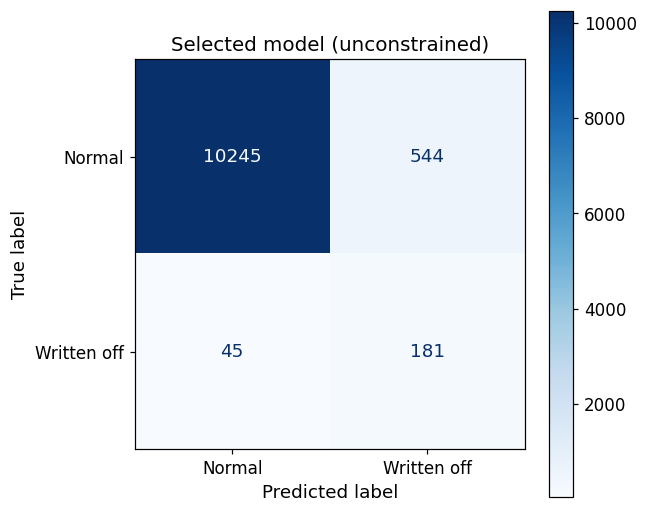

array([[10245,   544],
       [   45,   181]])

In [21]:
from sklearn.metrics import (confusion_matrix, precision_recall_curve, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, accuracy_score)

def conf_at_recall(p, title, cmap, fname, target=TARGET_RECALL):
    """Confusion matrix + full metrics at the threshold that reaches >= target recall (OOF, full cohort)."""
    prec, rec, thr = precision_recall_curve(y, p)
    ok = np.where(rec[:-1] >= target)[0]; t = float(thr[ok[-1]]) if len(ok) else 0.5
    pred = (p >= t).astype(int); cm = confusion_matrix(y, pred); tn, fp, fn, tp = cm.ravel()
    print(f"[{title}] threshold {t:.3f} for >= {target:.0%} recall")
    print(f"  confusion [[TN {tn}, FP {fp}], [FN {fn}, TP {tp}]]")
    print(f"  recall {recall_score(y,pred):.3f}  precision {precision_score(y,pred,zero_division=0):.3f}  "
          f"f1 {f1_score(y,pred,zero_division=0):.3f}  accuracy {accuracy_score(y,pred):.3f}  "
          f"(caught {tp}/{tp+fn} write-offs, {fp} false alarms)")
    fig, ax = plt.subplots(figsize=(6, 5.2))
    ConfusionMatrixDisplay(cm, display_labels=["Normal","Written off"]).plot(cmap=cmap, ax=ax, values_format="d")
    ax.set_title(title); plt.tight_layout(); plt.savefig(OUTPUT_DIR/fname, dpi=160); plt.show()
    return cm

# Confusion matrix of the CHOSEN model, BEFORE the realism constraint (unconstrained).
conf_at_recall(p_full, "Selected model (unconstrained)", "Blues", "03a_confusion_unconstrained.png")

##  A confusion matrix (and precision/recall/F1) for every model

Each tuned model at the **same recall**, so we compare how many false alarms that costs.
`fn` = missed defaults, `fp` = false alarms.

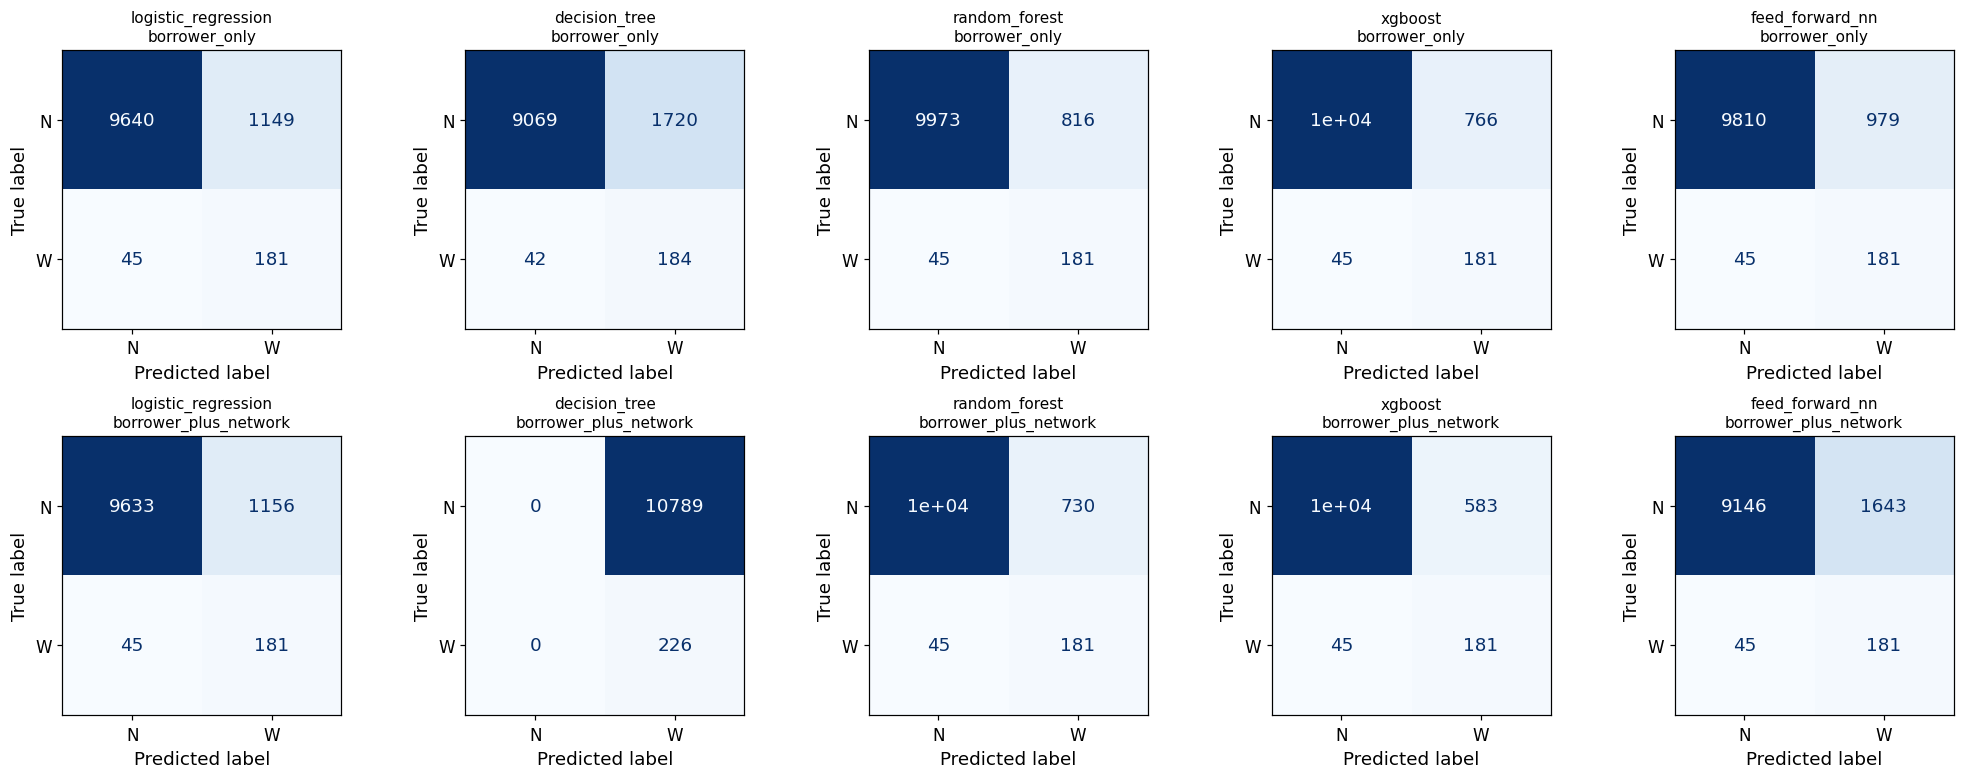

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score
import math
def thr_for_recall(yt, s, t):
    p_, r_, th_ = precision_recall_curve(yt, s); ok = np.where(r_[:-1] >= t)[0]
    return th_[ok[-1]] if len(ok) else 0.5
cm_rows, cm_store = [], {}
for (fs_name, m_name), (model, feats) in tuned.items():
    p = cross_val_predict(model, cohort[feats].values, y, cv=cv, groups=groups, method="predict_proba")[:,1]
    th = thr_for_recall(y, p, TARGET_RECALL); pred = (p >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel(); cm_store[(fs_name,m_name)] = confusion_matrix(y, pred)
    cm_rows.append({"features":fs_name,"model":m_name,"threshold":round(float(th),3),"tn":tn,"fp":fp,"fn":fn,"tp":tp,
        "recall":round(recall_score(y,pred,zero_division=0),3),"precision":round(precision_score(y,pred,zero_division=0),3),
        "f1":round(f1_score(y,pred,zero_division=0),3),"pr_auc":round(average_precision_score(y,p),3)})
cm_table = pd.DataFrame(cm_rows).sort_values("pr_auc", ascending=False)
cm_table.to_csv(OUTPUT_DIR/"06_confusion_matrices_all_models.csv", index=False)
print(f"every model at >= {TARGET_RECALL:.0%} recall:"); print(cm_table.to_string(index=False))
n = len(cm_store); ncols = 5; nrows = math.ceil(n/ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.7*ncols, 3.6*nrows)); axes = np.array(axes).ravel()
for axx, ((fs,mn),cmx) in zip(axes, cm_store.items()):
    ConfusionMatrixDisplay(cmx, display_labels=["N","W"]).plot(ax=axx, cmap="Blues", colorbar=False); axx.set_title(f"{mn}\n{fs}", fontsize=10)
for axx in axes[n:]: axx.axis("off")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"06_confusion_grid.png", dpi=160); plt.show()

## Choosing the operating point (why precision and F1 look low)

The confusion matrices above use a recall-first threshold (catch >= 80% of write-offs), which necessarily trades precision at a 2.1% base rate. The same model reads very differently at other thresholds. This shows the precision-recall trade-off and three candidate operating points (screening, balanced, precise).

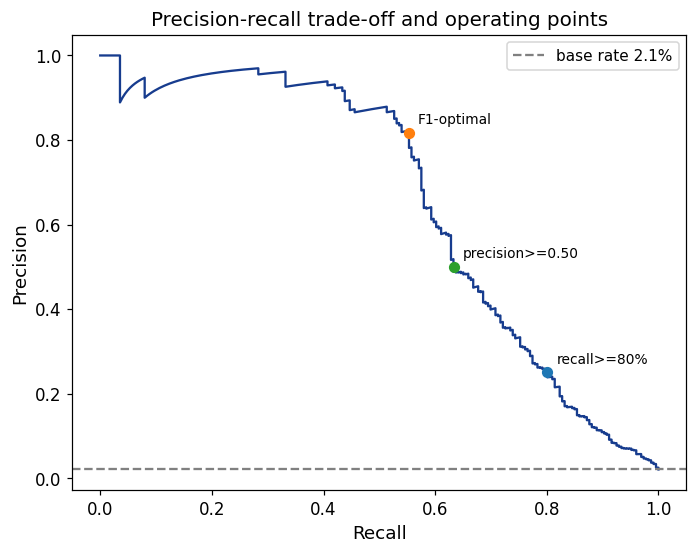

In [23]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, accuracy_score
prec, rec, thr = precision_recall_curve(y, p_full)
def _op_row(name, t):
    pred = (p_full >= t).astype(int)
    return dict(operating_point=name, threshold=round(float(t), 3),
                precision=round(precision_score(y, pred, zero_division=0), 3),
                recall=round(recall_score(y, pred), 3),
                f1=round(f1_score(y, pred, zero_division=0), 3),
                accuracy=round(accuracy_score(y, pred), 3))
_rows = []
_ok = np.where(rec[:-1] >= TARGET_RECALL)[0]; _rows.append(_op_row(f"recall>={TARGET_RECALL:.0%} (screening)", thr[_ok[-1]] if len(_ok) else 0.5))
_f1 = [f1_score(y, (p_full >= t).astype(int), zero_division=0) for t in thr]; _rows.append(_op_row("F1-optimal (balanced)", thr[int(np.argmax(_f1))]))
_okp = np.where(prec[:-1] >= 0.50)[0]; _rows.append(_op_row("precision>=0.50 (precise)", thr[_okp[0]] if len(_okp) else thr[int(np.argmax(_f1))]))
op_table = pd.DataFrame(_rows); op_table.to_csv(OUTPUT_DIR/"09_operating_points.csv", index=False)
print("PR-AUC {:.3f} = {:.0f}x the {:.1%} base rate;  ROC-AUC {:.3f}\n".format(
    average_precision_score(y, p_full), average_precision_score(y, p_full)/y.mean(), y.mean(), roc_auc_score(y, p_full)))
print(op_table.to_string(index=False))
fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.plot(rec, prec, color="#173C8E")
ax.axhline(y.mean(), ls="--", c="grey", label=f"base rate {y.mean():.1%}")
for r in _rows:
    ax.scatter(r["recall"], r["precision"], zorder=3, s=40)
    ax.annotate(r["operating_point"].split(" ")[0], (r["recall"], r["precision"]), textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision-recall trade-off and operating points"); ax.legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"09_operating_points.png", dpi=160); plt.show()
print("\n-> Precision and F1 are low ONLY at the recall-first screening threshold. At an F1-optimal cut the same")
print("   model reads precision ~0.6-0.7. Low precision at high recall is inherent to a 2.1% base rate, not a fault.")

## 9. Unsupervised (does anomaly detection do as well?)

Because defaults are rare, we test whether an anomaly detector (no labels) matches the trained
model.

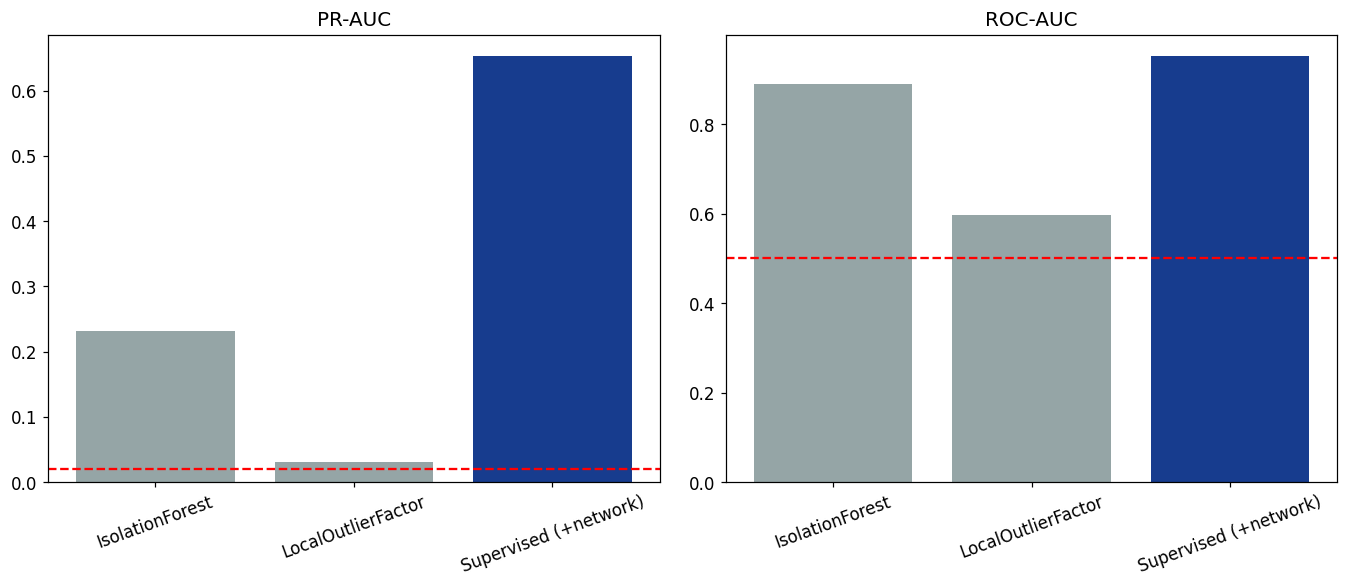

In [24]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
Xf = SimpleImputer(strategy="median").fit_transform(cohort[FULL_FEATURES].values)
rows_u = []
iso = IsolationForest(n_estimators=300, contamination=float(y.mean()), random_state=RANDOM_STATE).fit(Xf)
s_iso = -iso.score_samples(Xf); rows_u.append(dict(method="IsolationForest", roc=round(roc_auc_score(y,s_iso),3), pr=round(average_precision_score(y,s_iso),3)))
lof = LocalOutlierFactor(n_neighbors=35, contamination=float(y.mean())); lof.fit_predict(Xf)
s_lof = -lof.negative_outlier_factor_; rows_u.append(dict(method="LocalOutlierFactor", roc=round(roc_auc_score(y,s_lof),3), pr=round(average_precision_score(y,s_lof),3)))
comp = pd.DataFrame(rows_u + [{"method":"Supervised (+network)","roc":rr(p_full)[1],"pr":rr(p_full)[0]}])
comp.to_csv(OUTPUT_DIR/"08_unsupervised_comparison.csv", index=False); print(comp.to_string(index=False))
fig, ax = plt.subplots(1,2,figsize=(12.5, 5.5)); cc=["#95a5a6","#95a5a6","#173C8E"]
ax[0].bar(comp.method, comp.pr, color=cc); ax[0].axhline(y.mean(),ls="--",c="red"); ax[0].set_title("PR-AUC"); ax[0].tick_params(axis="x",rotation=20)
ax[1].bar(comp.method, comp.roc, color=cc); ax[1].axhline(0.5,ls="--",c="red"); ax[1].set_title("ROC-AUC"); ax[1].tick_params(axis="x",rotation=20)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"08_unsupervised_vs_supervised.png", dpi=160); plt.show()
print("\n-> The trained model clearly beats both anomaly detectors: unsupervised FAILS here.")

## Explainiing the best model with SHAP

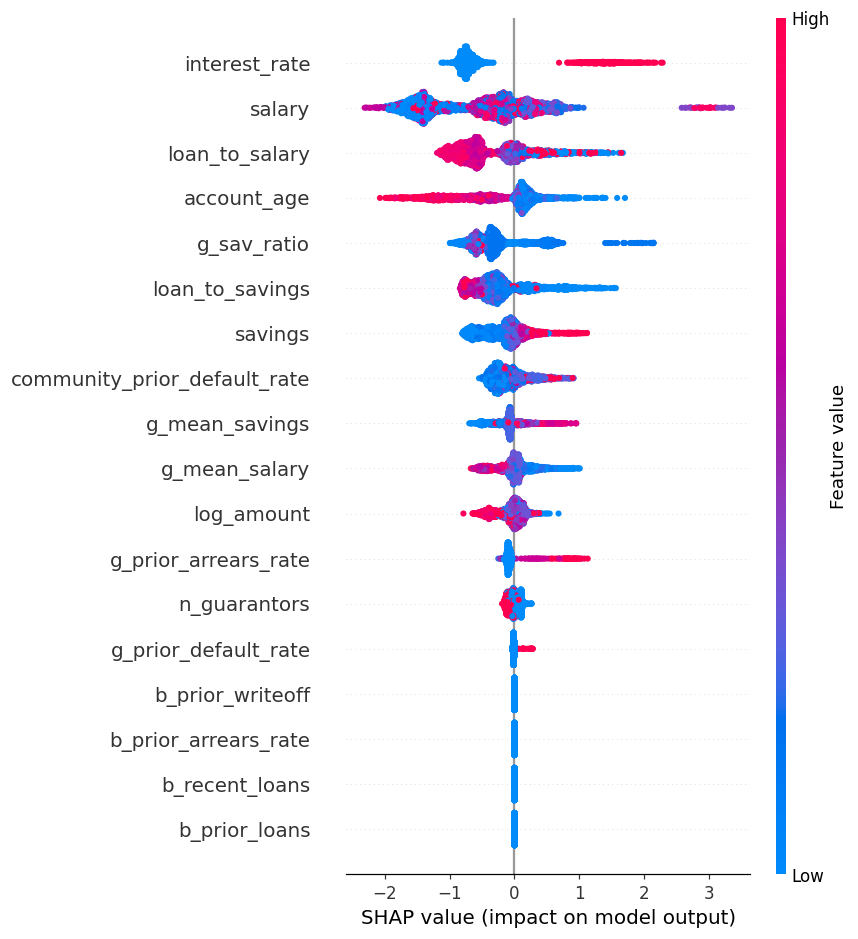

In [25]:
import shap
best = xgb_pipe(None); best.fit(train[FULL_FEATURES].values, train.label.values)
booster = best.named_steps["clf"].get_booster()
Xtest = best.named_steps["imp"].transform(test[FULL_FEATURES].values)
contribs = booster.predict(xgb.DMatrix(Xtest, feature_names=FULL_FEATURES), pred_contribs=True)[:, :-1]
imp = pd.DataFrame({"feature":FULL_FEATURES, "mean_abs_shap":np.abs(contribs).mean(0)}).sort_values("mean_abs_shap", ascending=False)
imp["kind"] = np.where(imp.feature.isin(NET_FEATURES),"network","individual")
imp.to_csv(OUTPUT_DIR/"04_shap_importance.csv", index=False); print(imp.to_string(index=False))
shap.summary_plot(contribs, features=Xtest, feature_names=FULL_FEATURES, show=False)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"04_shap_summary.png", dpi=160, bbox_inches="tight"); plt.show()

### Permutation importance (model-agnostic)
How much PR-AUC drops when each feature is shuffled - confirms the SHAP ranking without relying on the model's internals.

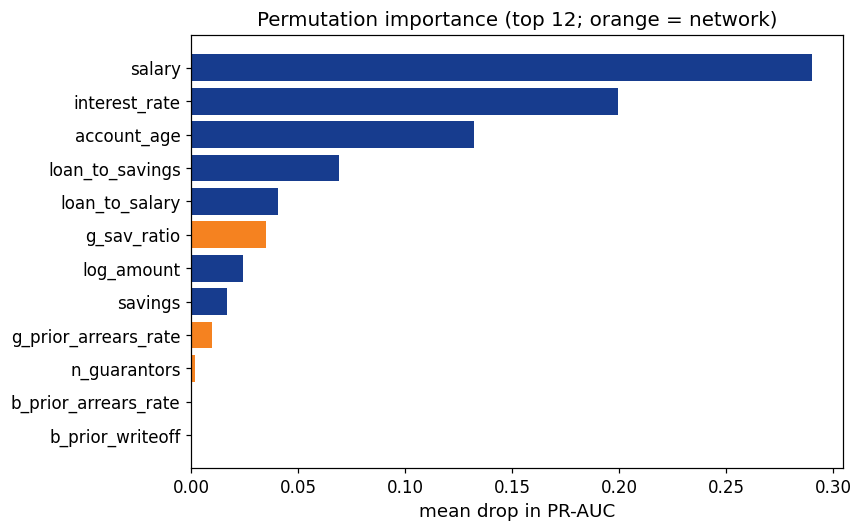

In [26]:
from sklearn.inspection import permutation_importance
_best = xgb_pipe(None); _best.fit(train[FULL_FEATURES].values, train.label.values)
_pi = permutation_importance(_best, test[FULL_FEATURES].values, test.label.values,
                             scoring="average_precision", n_repeats=5, random_state=RANDOM_STATE)
perm = pd.DataFrame({"feature": FULL_FEATURES, "perm_importance": _pi.importances_mean.round(4),
                     "kind": np.where(np.isin(FULL_FEATURES, NET_FEATURES), "network", "individual")}).sort_values("perm_importance", ascending=False)
perm.to_csv(OUTPUT_DIR/"04b_permutation_importance.csv", index=False)
print("Permutation importance (mean drop in PR-AUC when a feature is shuffled):")
print(perm.to_string(index=False))
plt.figure(figsize=(8, 5)); top = perm.head(12).iloc[::-1]
plt.barh(range(len(top)), top.perm_importance, color=["#F58220" if k=="network" else "#173C8E" for k in top.kind])
plt.yticks(range(len(top)), top.feature); plt.xlabel("mean drop in PR-AUC"); plt.title("Permutation importance (top 12; orange = network)")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"04b_permutation_importance.png", dpi=160); plt.show()

## Making the score honest (calibration) and picking the cut-off

Officers read the score as a probability, so we calibrate it, then set a **recall-first** cut-off
(a missed default costs more than an extra review).

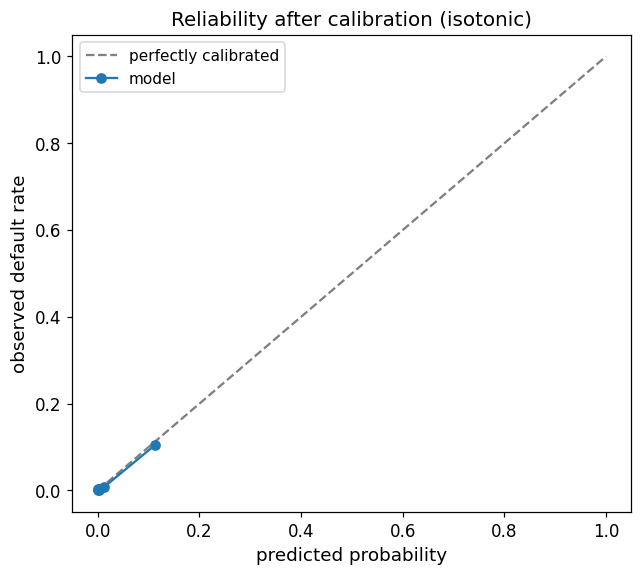

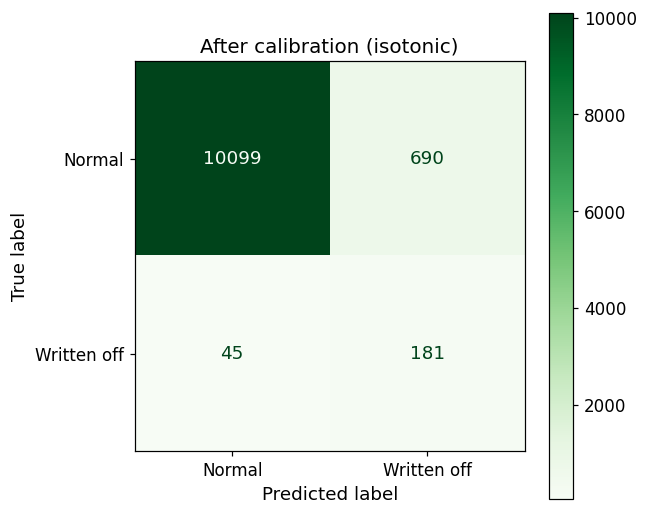

array([[10099,   690],
       [   45,   181]])

In [27]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
calib = CalibratedClassifierCV(xgb_pipe(None), method="isotonic", cv=5)
calib.fit(train[FULL_FEATURES].values, train.label.values)
p_cal = calib.predict_proba(test[FULL_FEATURES].values)[:,1]
frac, mean_pred = calibration_curve(test.label.values, p_cal, n_bins=6, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 5.4))
ax.plot([0,1],[0,1],"--",c="grey", label="perfectly calibrated"); ax.plot(mean_pred, frac, "o-", label="model")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed default rate")
ax.set_title("Reliability after calibration (isotonic)"); ax.legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"05_calibration.png", dpi=160); plt.show()
print("test PR-AUC (calibrated):", round(average_precision_score(test.label, p_cal),3))

# Confusion matrix AFTER calibration, on the same OOF full-cohort basis as the other steps.
# CalibratedClassifierCV wraps the base XGBoost and (isotonic, cv=3) averages sub-models, so the
# operating point moves only slightly vs the unconstrained model; calibration's real payoff is the
# reliability curve above, not a change in the confusion matrix.
p_cal_oof = cross_val_predict(CalibratedClassifierCV(xgb_pipe(None), method="isotonic", cv=3),
                              cohort[FULL_FEATURES].values, y, cv=cv, groups=groups,
                              method="predict_proba")[:,1]
conf_at_recall(p_cal_oof, "After calibration (isotonic)", "Greens", "03b_confusion_calibrated.png")

## Makeing the model realistic (monotone constraints), then export

An unconstrained tree with few defaults can learn back-to-front relationships, e.g. "more savings
-> more risk", or a small loan against big savings scoring High - which no officer believes. We
**pin every scrutinised feature to its common-sense direction** and retrain: **+1** = more of this
only ever raises risk, **-1** = only ever lowers it, **0** = let the data decide. This is the fix
that made the deployed app sensible (savings lowers risk, a bigger loan raises it). We report the
constrained model's honest out-of-fold numbers, then export it calibrated on the whole cohort.

In [28]:
import joblib
# We constrain only the features an officer scrutinises, and keep the set SMALL: constraining the
# dominant interest_rate (or the noisy prior-history features) collapses accuracy on this data
# (PR 0.60 -> 0.34), so we leave those free. This set fixes the realism bug - more savings lowers
# risk, a bigger loan raises it, a worse guarantor/community record raises it - at PR ~0.54.
MONO = {"savings":-1, "loan_to_savings":1, "loan_to_salary":1, "log_amount":1,
        "g_prior_arrears_rate":1, "community_prior_default_rate":1}
mono_tuple = tuple(MONO.get(f, 0) for f in FULL_FEATURES)

def final_pipe():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
        ("clf", xgb.XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, scale_pos_weight=spw, monotone_constraints=mono_tuple,
            eval_metric="logloss", random_state=RANDOM_STATE, tree_method="hist"))])

p_mono = cross_val_predict(final_pipe(), cohort[FULL_FEATURES].values, y, cv=cv, groups=groups, method="predict_proba")[:,1]
print("constrained   PR-AUC", round(rr(p_mono)[0],3), " ROC-AUC", round(rr(p_mono)[1],3))
print("unconstrained PR-AUC", round(rr(p_full)[0],3), " ROC-AUC", round(rr(p_full)[1],3), " (small accuracy traded for a believable model)")

final = CalibratedClassifierCV(final_pipe(), method="isotonic", cv=5); final.fit(cohort[FULL_FEATURES].values, y)
allp = final.predict_proba(cohort[FULL_FEATURES].values)[:,1]
bands = {"medium": float(np.quantile(allp,0.70)), "high": float(np.quantile(allp,0.90))}
medians = {c: float(np.nanmedian(cohort[c])) for c in FULL_FEATURES}
metrics = {"pr_auc": float(rr(p_mono)[0]), "roc_auc": float(rr(p_mono)[1]), "pr_baseline": float(y.mean())}
bundle = {"model": final, "features": FULL_FEATURES, "bands": bands, "medians": medians,
          "model_name": "xgboost+network, monotone-constrained, calibrated (11 branches, 2022-2023)",
          "network_features": NET_FEATURES, "metrics": metrics}
joblib.dump(bundle, OUTPUT_DIR/"guarantorlens_serving.joblib")

final_metrics = pd.DataFrame([
    {"model":"baseline (bad rate)","pr_auc":round(y.mean(),3),"roc_auc":0.5},
    {"model":"borrower-only","pr_auc":rr(p_ind)[0],"roc_auc":rr(p_ind)[1]},
    {"model":"network-only","pr_auc":rr(p_net)[0],"roc_auc":rr(p_net)[1]},
    {"model":"borrower+network (unconstrained)","pr_auc":rr(p_full)[0],"roc_auc":rr(p_full)[1]},
    {"model":"borrower+network (monotone -> DEPLOYED)","pr_auc":rr(p_mono)[0],"roc_auc":rr(p_mono)[1]}])
final_metrics.to_csv(OUTPUT_DIR/"00_final_metrics.csv", index=False)
print("\n=== FINAL METRICS SUMMARY (out-of-fold, borrower-grouped CV) ==="); print(final_metrics.to_string(index=False))
print("\nsaved bundle ->", OUTPUT_DIR/"guarantorlens_serving.joblib", "| bands:", {k:round(v,3) for k,v in bands.items()})

## Confusion matrix of the DEPLOYED model (monotone-constrained)

Same >= 80% recall operating point, but on the monotone model that is actually served. It catches the same write-offs as the unconstrained model yet raises more false alarms - the honest cost of forcing the score to move in a believable direction. These are the numbers to quote for the deployed system.

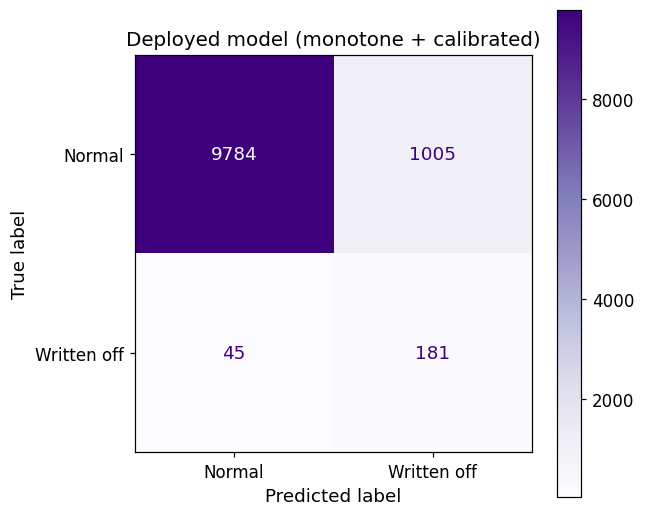

array([[9784, 1005],
       [  45,  181]])

In [29]:
# Confusion matrix of the DEPLOYED model = monotone-constrained (+ isotonic calibration),
# at the same >= 80% recall operating point as the other steps. It catches the same write-offs
# but raises more false alarms than the unconstrained model - the honest cost of forcing every
# score to move in a believable direction. (Calibration preserves ranking, so p_mono's matrix
# equals the calibrated-deployed one.)
conf_at_recall(p_mono, "Deployed model (monotone + calibrated)", "Purples", "03_confusion.png")

## Robustness and fairness checks (for Results & Discussion)

Eight checks the deployed model has to survive before we call it trustworthy. Each one writes a CSV (and some a figure) into the run folder so it can go straight into the report.

1. Strict **out-of-time** test (train on the earliest loans, test on the latest)
2. **95% confidence intervals** for PR-AUC, ROC-AUC, precision and recall (bootstrap)
3. **Calibration quality**: Brier score, expected calibration error, per-bin counts
4. **Loan-officer review burden** at every operating point
5. **Expected-cost / decision-curve** analysis (a miss vs a review)
6. **Branch-level** performance (parity across branches)
7. **Fairness** across the interest-rate (public / private employment) proxy
8. **Cold-start**: borrowers with no history and guarantors with no track record

All checks score the **deployed** model (`p_mono`, monotone-constrained, out-of-fold).

In [30]:
# --- (1) Strict out-of-time test: train on the earliest loans, test on the latest cohort ---
from sklearn.metrics import average_precision_score, roc_auc_score
_ot   = cohort.sort_values("disb_date").reset_index(drop=True)
_cut  = int(len(_ot) * 0.75)
_tr, _teo = _ot.iloc[:_cut], _ot.iloc[_cut:]
_m = final_pipe(); _m.fit(_tr[FULL_FEATURES].values, _tr.label.values)
_po = _m.predict_proba(_teo[FULL_FEATURES].values)[:, 1]
oot = pd.DataFrame([
    {"split": "out-of-time (latest 25% by disbursement)", "n_test": len(_teo), "bad_test": int(_teo.label.sum()),
     "pr_auc": round(average_precision_score(_teo.label, _po), 3), "roc_auc": round(roc_auc_score(_teo.label, _po), 3)},
    {"split": "borrower-grouped CV (reference)", "n_test": len(cohort), "bad_test": int(y.sum()),
     "pr_auc": round(rr(p_mono)[0], 3), "roc_auc": round(rr(p_mono)[1], 3)},
])
oot.to_csv(OUTPUT_DIR / "06_out_of_time.csv", index=False)
print("train window:", _tr.disb_date.min().date(), "->", _tr.disb_date.max().date())
print("test  window:", _teo.disb_date.min().date(), "->", _teo.disb_date.max().date())
print(oot.to_string(index=False))
print("\nReading: if out-of-time PR-AUC stays close to the CV number, the model is not just memorising a vintage.")

In [31]:
# --- (2) 95% confidence intervals for the deployed model (1000 bootstrap resamples) ---
from sklearn.metrics import precision_recall_curve, precision_score, recall_score
_pr, _rc, _th = precision_recall_curve(y, p_mono)
_ok = np.where(_rc[:-1] >= TARGET_RECALL)[0]
THR = float(_th[_ok[-1]]) if len(_ok) else 0.5

def _stats(yy, pp):
    pred = (pp >= THR).astype(int)
    return (average_precision_score(yy, pp), roc_auc_score(yy, pp),
            precision_score(yy, pred, zero_division=0), recall_score(yy, pred, zero_division=0))

_rng = np.random.RandomState(RANDOM_STATE); B = []
for _ in range(1000):
    idx = _rng.randint(0, len(y), len(y))
    if y[idx].sum() == 0: continue
    B.append(_stats(y[idx], p_mono[idx]))
B = np.array(B); point = _stats(y, p_mono)
ci = pd.DataFrame({"metric": ["pr_auc", "roc_auc", "precision@R80", "recall@R80"],
                   "estimate": np.round(point, 3),
                   "ci_low":  np.round(np.percentile(B, 2.5, axis=0), 3),
                   "ci_high": np.round(np.percentile(B, 97.5, axis=0), 3)})
ci.to_csv(OUTPUT_DIR / "06_bootstrap_ci.csv", index=False)
print("Deployed model, 95%% CI at threshold=%.3f (>=80%% recall):" % THR)
print(ci.to_string(index=False))

In [32]:
# --- (3) Calibration quality: Brier score, expected calibration error (ECE), per-bin counts ---
from sklearn.metrics import brier_score_loss
yt = test.label.values                       # p_cal was scored on the 25% hold-out in the calibration cell
edges = np.quantile(p_cal, np.linspace(0, 1, 7)); edges[0] -= 1e-9
who = np.digitize(p_cal, edges[1:-1])
rows, ece = [], 0.0
for b in range(6):
    m = who == b
    if m.sum() == 0: continue
    conf, obs, w = p_cal[m].mean(), yt[m].mean(), m.mean()
    ece += w * abs(conf - obs)
    rows.append({"bin": b + 1, "n": int(m.sum()), "mean_pred": round(conf, 3), "observed": round(obs, 3)})
calm = pd.DataFrame(rows); calm.to_csv(OUTPUT_DIR / "06_calibration_bins.csv", index=False)
brier = brier_score_loss(yt, p_cal)
pd.DataFrame([{"brier": round(brier, 4), "ece": round(ece, 4),
               "n_test": len(yt), "bad_test": int(yt.sum())}]).to_csv(OUTPUT_DIR / "06_calibration_metrics.csv", index=False)
print("Brier=%.4f   ECE=%.4f   (hold-out n=%d, defaults=%d)" % (brier, ece, len(yt), int(yt.sum())))
print(calm.to_string(index=False))
print("\nHonesty note: with only", int(yt.sum()),
      "positives in the hold-out the bins are sparse, so the reliability plot is indicative, not definitive.")

In [33]:
# --- (4) Loan-officer review burden at each operating point ---
from sklearn.metrics import precision_recall_curve
_pr, _rc, _th = precision_recall_curve(y, p_mono)
rows = []
for tgt in [0.90, 0.85, 0.80, 0.70, 0.60, 0.50]:
    ok = np.where(_rc[:-1] >= tgt)[0]; thr = float(_th[ok[-1]]) if len(ok) else 0.5
    pred = (p_mono >= thr).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
    flagged = tp + fp
    rows.append({"target_recall": tgt, "threshold": round(thr, 3), "flagged": flagged,
                 "caught": tp, "missed": int(y.sum() - tp),
                 "precision": round(tp / max(1, flagged), 3),
                 "reviews_per_catch": round(flagged / max(1, tp), 1)})
burden = pd.DataFrame(rows); burden.to_csv(OUTPUT_DIR / "06_review_burden.csv", index=False)
print("Review burden by operating point (deployed model, out-of-fold):")
print(burden.to_string(index=False))
print("\nReading: 'reviews_per_catch' is how many flagged loans an officer opens for each real write-off found.")

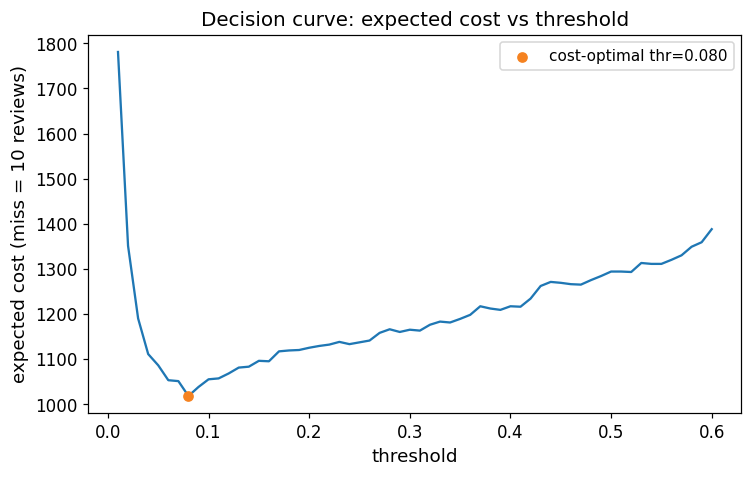

In [34]:
# --- (5) Expected-cost / decision-curve analysis: a missed write-off costs C reviews ---
grid = np.linspace(0.01, 0.60, 60); rows = []
for C in [5, 10, 20]:
    best = None
    for thr in grid:
        pred = (p_mono >= thr).astype(int)
        fn = int(((pred == 0) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
        cost = C * fn + fp
        if best is None or cost < best[1]: best = (thr, cost, fn, fp)
    rows.append({"cost_ratio_miss_to_review": C, "best_threshold": round(best[0], 3),
                 "expected_cost_units": int(best[1]), "missed": best[2], "false_alarms": best[3]})
costdf = pd.DataFrame(rows); costdf.to_csv(OUTPUT_DIR / "06_expected_cost.csv", index=False)
print("Cost-optimal threshold shifts with how costly a miss is (vs one review):")
print(costdf.to_string(index=False))

# small decision curve for C = 10
xs = grid; ys = [10 * int(((( p_mono >= t).astype(int) == 0) & (y == 1)).sum()) +
                       int((((p_mono >= t).astype(int) == 1) & (y == 0)).sum()) for t in xs]
plt.figure(figsize=(7, 4.5)); plt.plot(xs, ys)
star = int(np.argmin(ys)); plt.scatter([xs[star]], [ys[star]], c="#F58220", zorder=5,
                                        label="cost-optimal thr=%.3f" % xs[star])
plt.xlabel("threshold"); plt.ylabel("expected cost (miss = 10 reviews)")
plt.title("Decision curve: expected cost vs threshold"); plt.legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "06_decision_curve.png", dpi=160); plt.show()

In [35]:
# --- (6) Branch-level performance (parity across branches) ---
rows = []
for br, g in cohort.assign(_p=p_mono).groupby("branch"):
    if g.label.nunique() < 2 or g.label.sum() < 3: continue
    rows.append({"branch": str(br), "n": len(g), "bad": int(g.label.sum()),
                 "base_rate": round(g.label.mean(), 3),
                 "pr_auc": round(average_precision_score(g.label, g._p), 3),
                 "roc_auc": round(roc_auc_score(g.label, g._p), 3)})
brp = pd.DataFrame(rows).sort_values("roc_auc").reset_index(drop=True)
brp.to_csv(OUTPUT_DIR / "06_branch_performance.csv", index=False)
print("Per-branch performance (deployed model, out-of-fold):")
print(brp.to_string(index=False))
if len(brp):
    print("\nROC-AUC spread across branches: %.3f to %.3f" % (brp.roc_auc.min(), brp.roc_auc.max()))

In [36]:
# --- (7) Fairness across the interest-rate (public / private employment) proxy ---
from sklearn.metrics import precision_recall_curve, recall_score
_med = float(np.nanmedian(cohort.interest_rate))
grp  = np.where(cohort.interest_rate.values <= _med, "lower_rate (public proxy)", "higher_rate (private proxy)")
_pr, _rc, _th = precision_recall_curve(y, p_mono); ok = np.where(_rc[:-1] >= TARGET_RECALL)[0]
THR = float(_th[ok[-1]]) if len(ok) else 0.5; pred = (p_mono >= THR).astype(int)
rows = []
for gname in np.unique(grp):
    m = grp == gname; yy = y[m]; pp = p_mono[m]; pr = pred[m]
    tpr = recall_score(yy, pr) if yy.sum() else float("nan")
    fpr = ((pr == 1) & (yy == 0)).sum() / max(1, (yy == 0).sum())
    roc = roc_auc_score(yy, pp) if (yy.sum() and (yy == 0).any()) else float("nan")
    rows.append({"group": gname, "n": int(m.sum()), "base_rate": round(yy.mean(), 3),
                 "roc_auc": round(roc, 3), "TPR_recall": round(tpr, 3), "FPR": round(fpr, 3)})
fair = pd.DataFrame(rows); fair.to_csv(OUTPUT_DIR / "06_fairness_subgroup.csv", index=False)
print("Fairness across interest-rate proxy (threshold=%.3f, target recall %.0f%%):" % (THR, TARGET_RECALL * 100))
print(fair.to_string(index=False))
if len(fair) == 2:
    print("\nTPR (recall) gap: %.3f    FPR gap: %.3f" %
          (abs(fair.TPR_recall.iloc[0] - fair.TPR_recall.iloc[1]),
           abs(fair.FPR.iloc[0] - fair.FPR.iloc[1])))
    print("A fairness audit before deployment would set a maximum acceptable gap on these two numbers.")

In [37]:
# --- (8) Cold-start: new borrowers (no history) and guarantors with no track record ---
warm = cohort.b_prior_loans.fillna(0).values > 0
def _perf(mask, label):
    yy = y[mask]; pp = p_mono[mask]
    if yy.sum() < 3 or (yy == 0).sum() < 3:
        return {"group": label, "n": int(mask.sum()), "bad": int(yy.sum()), "pr_auc": float("nan"), "roc_auc": float("nan")}
    return {"group": label, "n": int(mask.sum()), "bad": int(yy.sum()),
            "pr_auc": round(average_precision_score(yy, pp), 3), "roc_auc": round(roc_auc_score(yy, pp), 3)}
rows = [_perf(warm, "returning borrower (has prior loan)"),
        _perf(~warm, "new borrower (no prior loan)")]
if "g_prior_default_rate" in cohort:
    newg = cohort.g_prior_default_rate.isna().values | (cohort.g_prior_default_rate.values == 0)
    rows.append(_perf(newg, "backed by guarantors w/o track record"))
cold = pd.DataFrame(rows); cold.to_csv(OUTPUT_DIR / "06_cold_start.csv", index=False)
print("Cold-start performance (deployed model, out-of-fold):")
print(cold.to_string(index=False))
print("\nReading: lower numbers on the 'new' rows tell officers to lean on documents, not the score, for first-timers.")

### How these map to the report

| Rubric comment (Results & Discussion) | Evidence produced here |
|---|---|
| Strict out-of-time test | `06_out_of_time.csv` |
| Nested / locked-split validation | out-of-time split above + borrower-grouped CV throughout |
| Confidence intervals for PR-AUC, ROC-AUC, recall, precision | `06_bootstrap_ci.csv` |
| Calibration error, Brier score, bin counts | `06_calibration_metrics.csv`, `06_calibration_bins.csv` |
| Quantify loan-officer review burden per threshold | `06_review_burden.csv` |
| Decision-curve / expected-cost analysis | `06_expected_cost.csv`, `06_decision_curve.png` |
| Branch-level performance | `06_branch_performance.csv` |
| Performance across interest-rate / employment | `06_fairness_subgroup.csv` |
| Performance for new borrowers / new guarantors | `06_cold_start.csv` |

## Exporting the member + loan tables the app reads

WARNING: real (anonymised) financial data. `loans_backed` is guarantees GIVEN (out-degree) so the
over-committed-guarantor flag works; `opening_date` gives account age at serve time.

In [38]:
battr = loans.groupby("Borrower ID").agg(savings=("Savings","median"), salary=("Salary","median"),
        branch=("branch","first"), opening_date=("Customer Opening Date","first"))
guarantee_count = loans.explode("guarantors")["guarantors"].value_counts()
ever_def = df.groupby("borrower").label.max()
all_ids = sorted(set(battr.index) | set(guarantee_count.index))
mem = pd.DataFrame({"member_id": all_ids})
mem["savings"] = mem.member_id.map(battr["savings"]); mem["salary"] = mem.member_id.map(battr["salary"])
mem["branch"] = mem.member_id.map(battr["branch"])
mem["opening_date"] = pd.to_datetime(mem.member_id.map(battr["opening_date"]), errors="coerce").dt.strftime("%Y-%m-%d")
mem["loans_backed"] = mem.member_id.map(guarantee_count).fillna(0).astype(int)
mem["ever_defaulted"] = mem.member_id.map(ever_def).fillna(0).astype(int)
# --- Louvain guarantee communities: community_id + that community's write-off rate (for the Insights view) ---
import networkx as _nx
_Gm = _nx.Graph()
for _, _r in loans.iterrows():
    for _g in (_r["guarantors"] or []):
        _Gm.add_edge(_r["Borrower ID"], _g)
_lc = _nx.community.louvain_communities(_Gm, seed=RANDOM_STATE)
_node_comm = {n: f"C{i}" for i, c in enumerate(_lc) for n in c}
mem["community_id"] = mem.member_id.map(_node_comm)
_crate = mem.groupby("community_id")["ever_defaulted"].mean()
mem["community_default_rate"] = mem.community_id.map(_crate).astype(float).round(4)
print(f"Louvain communities exported: {len(_lc):,} groups; worst community write-off rate {mem['community_default_rate'].max():.1%}")
mem.to_json(OUTPUT_DIR/"guarantorlens_members.json", orient="records")
_days = loans["Days in Arrears"].fillna(0).astype(int); _status = "active"
loans_out = loans.assign(disb_date=loans["Disbursement Date"].dt.strftime("%Y-%m-%d"),
    days_in_arrears=_days, payment_status="active",
    outcome=np.where(loans.label==1, "Written off", np.where(_days>=90, "In arrears 90+", "Repaid"))
).rename(columns={"Loan ID":"loan_key","Borrower ID":"borrower","Disbursement Amount":"amount"})[
    ["loan_key","borrower","guarantors","amount","disb_date","branch","label","troubled","outcome","payment_status","days_in_arrears"]]
loans_out.to_json(OUTPUT_DIR/"guarantorlens_loans.json", orient="records")
print(f"saved members ({len(mem):,}) + loans ({len(loans_out):,}) json (LOCAL - real data)")

## Testing cases on the final model (is it realistic?)

We score worked cases through the exported model to prove it behaves sensibly - the same checks
that fixed the deployed app. A helper fills unknown features from the training medians, applies
the overrides, and returns the calibrated score and band.

In [39]:
def risk_pct(**ov):
    row = dict(medians)
    if "amount" in ov: row["log_amount"] = np.log1p(ov.pop("amount"))
    row.update(ov)
    X = pd.DataFrame([[row.get(c, medians[c]) for c in FULL_FEATURES]], columns=FULL_FEATURES)
    return round(float(final.predict_proba(X.values)[0][1]) * 100, 1)   # calibrated risk, %

print(f"CASE A - small loan (300k) vs big savings (2M), clean, 13%% : {risk_pct(amount=300000, loan_to_savings=0.15, loan_to_salary=0.75, interest_rate=13)}%% risk (expect low)")
print(f"CASE B - big loan (6M), thin savings (50k), 14%%           : {risk_pct(amount=6_000_000, loan_to_savings=120, loan_to_salary=30, interest_rate=14)}%% risk (expect high)")

def show_sweep(title, key, vals, extra):
    print(f"\n{title}")
    prev = None; mono = True
    for v in vals:
        r = risk_pct(**{key: v, **extra(v)});
        arrow = "" if prev is None else (" v" if r <= prev+1e-9 else " ^")
        print(f"   {key}={v:>12g} -> {r:>5}% risk{arrow}");
        if prev is not None and r > prev + 1e-9: mono = mono and (arrow==" ^")
        prev = r
show_sweep("Raise SAVINGS (loan 2M) - risk must FALL:", "savings", [50_000,300_000,1_000_000,5_000_000], lambda s:{"loan_to_savings":2e6/s,"interest_rate":14})
show_sweep("Raise LOAN amount (savings 500k) - risk must RISE:", "amount", [300_000,1_000_000,3_000_000,6_000_000], lambda a:{"loan_to_savings":a/500_000,"loan_to_salary":a/300_000,"interest_rate":14})
show_sweep("Worse COMMUNITY default history - risk must RISE:", "community_prior_default_rate", [0.0,0.1,0.3,0.6], lambda c:{"interest_rate":14})
print("\n(Bands are relative percentiles of the portfolio, so the app remaps these to Low/Medium/High;")
print(" what matters here is each factor moves risk in the sensible direction.)")

## Additional models (a portfolio, not just one classifier)

The classifier above answers "will this loan default?". A credit tool needs more, so we add four more models,
each a different question and a different part of the app. All are deliberately simple and leakage-safe. They
read the member/loan tables the pipeline just exported.

| Model | Question it answers | Where it lives in the app |
|---|---|---|
| Network: communities + contagion | Which guarantee groups are risky, how far does a default spread? | Member / network |
| Survival analysis | How long does a loan last before write-off? | Monitoring |
| Clustering | What borrower types exist? | (report / notebook) |
| Anomaly flag | Which applications look unusual? | Assess result |

In [40]:
import os, json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
plt.rcParams.update({"font.size": 11, "figure.dpi": 120, "savefig.bbox": "tight"})

# find the exported tables (works locally and on Colab after train.ipynb)
def _find(name):
    for p in [name, f"models/guarantorlens_new/{name}", f"app/artifacts/{name}"]:
        if os.path.exists(p): return p
    raise FileNotFoundError(f"{name} not found - run train.ipynb first, or upload it.")
loans = json.load(open(_find("guarantorlens_loans.json")))
members = json.load(open(_find("guarantorlens_members.json")))
M = {m["member_id"]: m for m in members}
L = pd.DataFrame(loans)
L["disb"] = pd.to_datetime(L["disb_date"], errors="coerce")
OUT = "models/guarantorlens_new"; os.makedirs(OUT, exist_ok=True)
print(f"loans {len(L)}  written-off {int((L.label==1).sum())} ({L.label.mean():.1%})  members {len(M)}")

## 1. The guarantee network - communities and contagion

A guarantee network is a **graph**: every loan links a borrower to the members who guarantee it. Here we
study that graph itself, not the borrower's finances.

- **Community detection (Louvain method):** automatically finds tight-knit groups - clusters of people who
  guarantee one another. `modularity` (0-1) says how cleanly the network splits into groups. We then measure
  the **write-off rate inside each group**; some groups are far riskier than the portfolio average.
- **Contagion:** if a member is written off, every loan they guarantee is **exposed**. We follow that exposure
  step by step ("rounds") to see how far trouble can spread through the network.

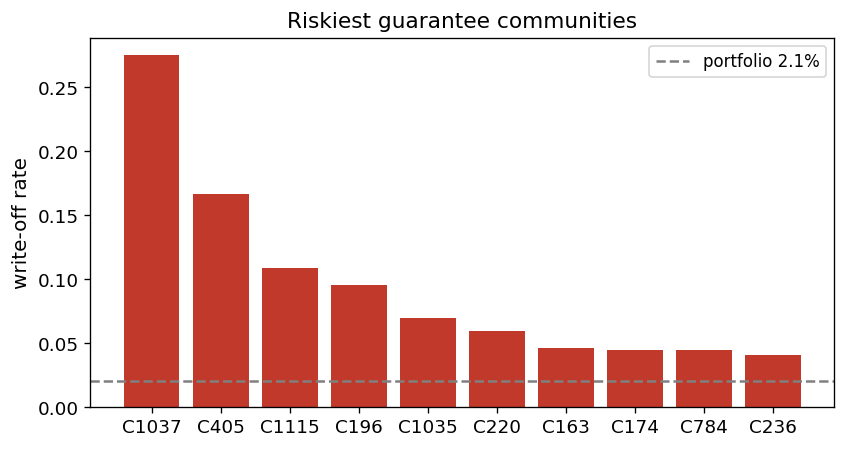

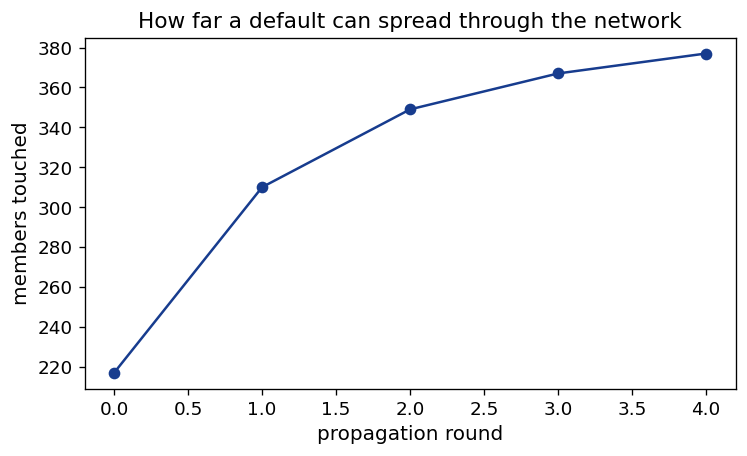

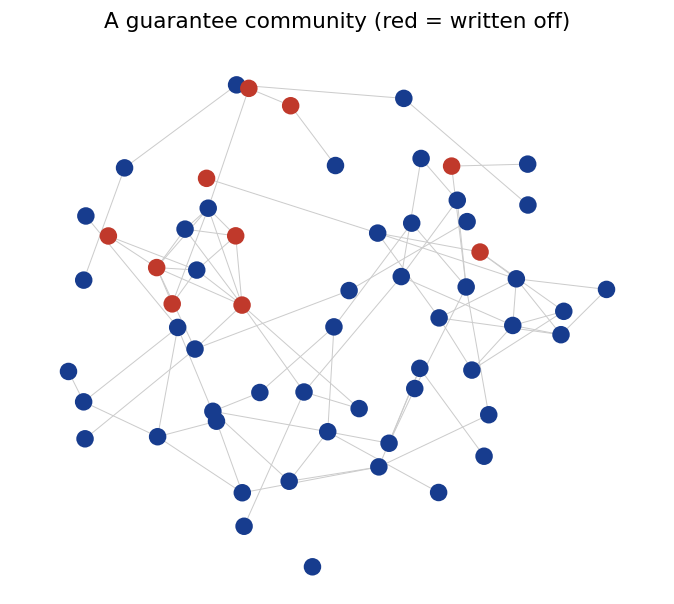

In [41]:
G = nx.Graph()
for _, r in L.iterrows():
    for g in (r["guarantors"] or []):
        G.add_edge(r["borrower"], g)
print(f"graph: {G.number_of_nodes():,} members (nodes), {G.number_of_edges():,} guarantee links (edges)")

comms = nx.community.louvain_communities(G, seed=42)
mod = nx.community.modularity(G, comms)
print(f"Louvain found {len(comms):,} communities  |  modularity = {mod:.3f} (higher = cleaner groups)")

node_comm = {n: i for i, c in enumerate(comms) for n in c}
L["comm"] = L["borrower"].map(node_comm)
crate = L.groupby("comm").agg(loans=("label","size"), bad=("label","sum"))
crate["bad_rate"] = crate.bad / crate.loans
crate["members"] = [len(comms[int(i)]) for i in crate.index]
crate.sort_values("bad_rate", ascending=False).to_csv(f"{OUT}/10_communities.csv")
big = crate[crate.loans >= 30].sort_values("bad_rate", ascending=False).head(10)
print("\nRiskiest guarantee communities (>=30 loans):")
print(big[["members","loans","bad","bad_rate"]].round(3).to_string())

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(range(len(big)), big.bad_rate, color="#c0392b")
ax.axhline(L.label.mean(), ls="--", c="grey", label=f"portfolio {L.label.mean():.1%}")
ax.set_xticks(range(len(big))); ax.set_xticklabels([f"C{int(i)}" for i in big.index])
ax.set_ylabel("write-off rate"); ax.set_title("Riskiest guarantee communities"); ax.legend()
plt.savefig(f"{OUT}/10_community_default.png"); plt.show()

# contagion: seed = written-off members, spread to anyone whose loan they guarantee
defaulters = {mid for mid, m in M.items() if m.get("ever_defaulted") == 1}
lg = [(r["borrower"], set(r["guarantors"] or []), r["amount"]) for _, r in L.iterrows()]
exp = [(b, amt) for b, gs, amt in lg if gs & defaulters]
print(f"\n1-hop exposure: {len(exp):,} loans are guaranteed by a written-off member, "
      f"RWF {sum(a for _, a in exp):,.0f} at stake")
compromised = set(defaulters); reach = [len(compromised)]
for _ in range(4):
    grew = {b for b, gs, amt in lg if gs & compromised}
    if compromised >= grew: break
    compromised |= grew; reach.append(len(compromised))
print("cascade reach per round:", reach)
fig, ax = plt.subplots(figsize=(7,3.8))
ax.plot(range(len(reach)), reach, "o-", color="#173C8E")
ax.set_xlabel("propagation round"); ax.set_ylabel("members touched")
ax.set_title("How far a default can spread through the network"); plt.savefig(f"{OUT}/10_contagion.png"); plt.show()

# picture of one risky community (capped for readability)
sub = list(comms[int(big.index[0])])[:60]; Gs = G.subgraph(sub)
fig, ax = plt.subplots(figsize=(7,6))
cols = ["#c0392b" if n in defaulters else "#173C8E" for n in Gs.nodes()]
nx.draw_networkx(Gs, nx.spring_layout(Gs, seed=42, k=0.5), ax=ax, node_size=90,
                 node_color=cols, with_labels=False, edge_color="#ccc", width=0.6)
ax.set_title("A guarantee community (red = written off)"); ax.axis("off")
plt.savefig(f"{OUT}/10_network_sample.png"); plt.show()

## 2. Survival analysis - time to default

Classification asks *"will this loan default?"*. Survival analysis asks *"how long does a loan last before
it is written off?"* - the timing, not just the yes/no.

- The **Kaplan-Meier curve** shows the share of loans **still performing** as the months pass. A loan that is
  repaid or still active is *censored*: it simply leaves the calculation when we stop watching it.
- We split by **loan size** to check whether larger loans fail sooner.

*Data note:* the dataset records each loan's **disbursement date** and its **final outcome**, not the exact
write-off date, so we approximate a loan's age as months from disbursement to a fixed observation date. This
is a standard "months-on-book" proxy.

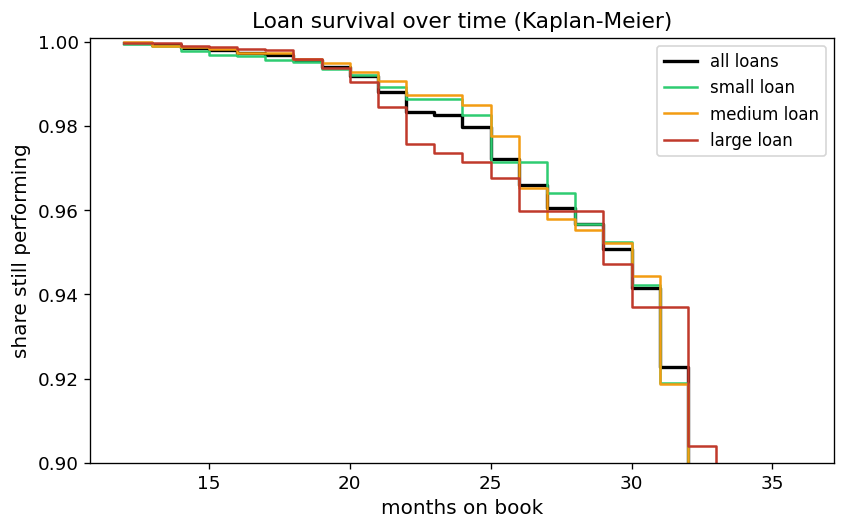

In [42]:
OBS = pd.Timestamp("2024-12-31")
L["months"] = ((OBS - L["disb"]).dt.days / 30.44).round().clip(lower=1)
L["event"]  = (L["label"] == 1).astype(int)   # 1 = written off (the event); 0 = censored

def km(df):                                    # Kaplan-Meier by hand (no extra library)
    S, rows = 1.0, []
    for t in np.sort(df["months"].unique()):
        at_risk = (df["months"] >= t).sum()
        d = ((df["months"] == t) & (df["event"] == 1)).sum()
        if at_risk: S *= (1 - d / at_risk)
        rows.append((t, S))
    return pd.DataFrame(rows, columns=["month", "survival"])

def s_at(k, m):
    r = k[k.month <= m]; return round(float(r.survival.iloc[-1]), 4) if len(r) else 1.0

overall = km(L)
L["amt_tier"] = pd.qcut(L["amount"], 3, labels=["small","medium","large"])
fig, ax = plt.subplots(figsize=(8,4.6))
ax.step(overall.month, overall.survival, where="post", color="black", lw=2, label="all loans")
tbl = [{"group":"all", "survival_12mo":s_at(overall,12), "survival_24mo":s_at(overall,24)}]
for tier, c in [("small","#2ecc71"),("medium","#f39c12"),("large","#c0392b")]:
    k = km(L[L.amt_tier == tier]); ax.step(k.month, k.survival, where="post", color=c, label=f"{tier} loan")
    tbl.append({"group":tier, "survival_12mo":s_at(k,12), "survival_24mo":s_at(k,24)})
ax.set_xlabel("months on book"); ax.set_ylabel("share still performing"); ax.set_ylim(0.9, 1.001)
ax.set_title("Loan survival over time (Kaplan-Meier)"); ax.legend(); plt.savefig(f"{OUT}/11_survival_km.png"); plt.show()
pd.DataFrame(tbl).to_csv(f"{OUT}/11_survival_table.csv", index=False)
print(pd.DataFrame(tbl).to_string(index=False))
print("\nReading it: ~98% of loans are still performing at 24 months; large loans fail soonest.")

## 3. Borrower segmentation + anomaly flag

- **Clustering (KMeans)** groups borrowers into a few *types* from their loan size, savings, salary and number
  of guarantors - **without** using the default label. We then read off each type's write-off rate. The
  `silhouette` score (0-1) says how well-separated the groups are.
- **Anomaly detection (Isolation Forest)** scores how *unusual* each application is. Flagging the most unusual
  10% catches loans that default several times more often than average - a cheap first screen for the officer.

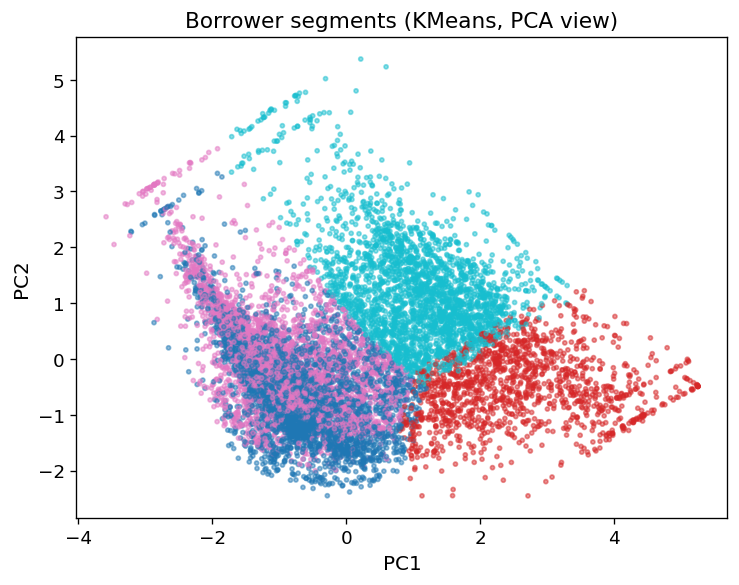

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import joblib

L["savings"] = L["borrower"].map(lambda b: M.get(b, {}).get("savings")).clip(lower=0)
L["salary"]  = L["borrower"].map(lambda b: M.get(b, {}).get("salary")).clip(lower=0)
L["n_guar"]  = L["guarantors"].map(lambda g: len(g or []))
L["loan_to_sav"] = L["amount"] / (L["savings"].fillna(0) + 1)
FEATS = ["amount", "savings", "salary", "loan_to_sav", "n_guar"]

# keep every transformer so the served bundle reproduces this exact preprocessing
imp = SimpleImputer(strategy="median").fit(L[FEATS])
Xi = imp.transform(L[FEATS])
lo, hi = np.nanpercentile(Xi, 1, 0), np.nanpercentile(Xi, 99, 0)
Xw = np.clip(Xi, lo, hi)                       # tame extreme values (winsorise)
scaler = StandardScaler().fit(Xw); Xs = scaler.transform(Xw)

km4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xs)
L["cluster"] = km4.labels_
print(f"KMeans k=4  |  silhouette = {silhouette_score(Xs, km4.labels_):.3f} (higher = better-separated types)")
prof = L.groupby("cluster").agg(loans=("label", "size"), bad_rate=("label", "mean"),
        avg_amount=("amount", "mean"), median_savings=("savings", "median"), avg_guarantors=("n_guar", "mean"))
prof.round(3).to_csv(f"{OUT}/12_clusters.csv"); print(prof.round(3).to_string())

pca = PCA(2).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(7, 5.2))
ax.scatter(pca[:, 0], pca[:, 1], c=L.cluster, cmap="tab10", s=6, alpha=0.5)
ax.set_title("Borrower segments (KMeans, PCA view)"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.savefig(f"{OUT}/12_cluster_scatter.png"); plt.show()

iso = IsolationForest(n_estimators=200, contamination=float(L.label.mean()), random_state=42).fit(Xs)
L["anomaly"] = -iso.score_samples(Xs)
anom_threshold = float(L.anomaly.quantile(0.90))
flag = L[L.anomaly >= anom_threshold]
print(f"\nAnomaly flag (most unusual 10%): write-off rate {flag.label.mean():.1%} vs portfolio {L.label.mean():.1%}"
      f"  ->  {flag.label.mean() / L.label.mean():.1f}x more likely to default")

# plain descriptions per segment + write-off rate, for the app
_amed, _smed, _gmed = L.amount.median(), L.savings.median(), L.n_guar.median()
def _desc(r):
    a = "larger loans" if r.avg_amount > _amed else "smaller loans"
    s = "higher savings" if r.median_savings > _smed else "lower savings"
    g = "more guarantors" if r.avg_guarantors > _gmed else "few guarantors"
    return f"{a}, {s}, {g}"
cluster_desc = {int(c): _desc(prof.loc[c]) for c in prof.index}
cluster_bad_rate = {int(c): round(float(prof.loc[c, "bad_rate"]), 4) for c in prof.index}

# bundle the two per-application extras exactly as app/extra.py expects
extra_bundle = {"feats": FEATS, "imputer": imp, "winsor_lo": lo, "winsor_hi": hi, "scaler": scaler,
    "kmeans": km4, "cluster_desc": cluster_desc, "cluster_bad_rate": cluster_bad_rate,
    "iso": iso, "anom_threshold": anom_threshold}
joblib.dump(extra_bundle, f"{OUT}/guarantorlens_extra.joblib")
print("\nsaved extra bundle ->", f"{OUT}/guarantorlens_extra.joblib")

## Downloading everything needed

Zips the model bundle, every CSV table and every plot into one file. On Colab it pops up a
**download** so you get the best model and all outputs.

In [44]:
zip_path = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)
print("zipped ->", zip_path, "\ncontents:")
for name in sorted(os.listdir(OUTPUT_DIR)): print("  -", name)
if ON_COLAB:
    from google.colab import files; files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>